# Runoff Ratio Analysis

Here, we will first compare the results of all model types for the east river for wet, normal, and dry years between 2000 and 2021. 

Then we will analyze the runoff ratio variability from each model. We will also include a baseline SWE-Q regression model using the Butte snotel and observed streamflow relationship. 

In [1]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from pathlib import Path
import glob
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()
from utils.custom import linear_reservoir

In [2]:
DATA_DIR = Path("/scratch/dlhogan/ess-project-data/")
DOMAIN = "East_River"
lumped_dir = DATA_DIR / f"domain_{DOMAIN}_lumped" / "simulations" / "best_simulations"
distributed_elev_dir = DATA_DIR / f"domain_{DOMAIN}_distributed" / "simulations" / "best_simulations"
distributed_elev_aspect_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect" / "simulations" / "best_simulations"
distributed_elev_TPI_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI" / "simulations" / "best_simulations"

In [107]:
# get East precipitation data from forcining
FORCING_DIR = Path(F"/scratch/dlhogan/ess-project-data/domain_{DOMAIN}_lumped/forcing")
precip_files = sorted(glob.glob(str(FORCING_DIR / "SUMMA_input" / "*metsim*.nc")))

ppt_dss = []
for file in precip_files:
    ds = xr.open_dataset(file)['pptrate'].resample(time='1D').mean()*3600*24
    ppt_dss.append(ds)
    ds.close()

# merge datasets
wy_precip = xr.concat(ppt_dss, dim='time').resample(time='YS-OCT').sum()
# winter_precip = xr.concat(ppt_dss, dim='time')
# # water year winter is december - march
# winter_precip = winter_precip.where(winter_precip['time.month'].isin([12, 1, 2, 3])).resample(time='YS-DEC').sum()

In [108]:
wy_precip_df = wy_precip.to_dataframe() 
# remove hru index
wy_precip_df = wy_precip_df.reset_index(level='hru')
wy_precip_df.index = wy_precip_df.index.year + 1

In [109]:
# observed streamflow
obs_streamflow = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "streamflow_obs.csv", 
                             parse_dates=['date'], 
                             index_col='date')

In [110]:
lumped_files = sorted(glob.glob(str(lumped_dir / "*.nc")))
distributed_elev_files = sorted(glob.glob(str(distributed_elev_dir / "*.nc")))
distributed_elev_aspect_files = sorted(glob.glob(str(distributed_elev_aspect_dir / "*.nc")))
# distributed_elev_TPI_files = sorted(glob.glob(str(distributed_elev_TPI_dir / "*.nc")))

In [111]:
east_linear_reservoir_params = {
                            "lumped":
                            {"noXplict_zeroFlux":{'k_fast': 0.03843939030166468, 'k_slow': 0.03755405444510841, 'f_fast': 1.0},
                             "noXplict_drainage": {'k_fast': 0.06308111559524023, 'k_slow': 0.001475925014222625, 'f_fast': 0.6052602949996202},
                             "bigBuckt": "averageInstantRunoff",},
                            "distributed_elev":
                            {"noXplict_drainage":{'k_fast': 0.054340140421693967, 'k_slow': 0.0003932011558550064, 'f_fast': 0.6052602949996202},
                             "bigBuckt": {'k_fast': 0.7729497280965281, 'k_slow': 2.1803944632295234e-07, 'f_fast': 0.8253809118991199}, # or averageInstantRunoff
                             "qTopmodl":{'k_fast': 0.07815593491892166, 'k_slow': 8.302487117517937e-05, 'f_fast': 0.6052602949996202}},
                            "distributed_elevAspect":
                            {"noXplict_drainage": {'k_fast': 0.10132269760097318, 'k_slow': 0.0003703317283164696, 'f_fast': 0.6395810725483903},
                             "bigBuckt": {'k_fast': 0.4729497280965281, 'k_slow': 2.1803944632295235e-05, 'f_fast': 0.7853809118991199},
                             "qTopmodl": {'k_fast': 0.05472818779380724, 'k_slow': 0.0023037617204891884, 'f_fast': 0.6391567712268422}},
                            "distributed_elevTPI":
                            {"noXplict_drainage": {'k_fast': 0.4464056315785419, 'k_slow': 0.00017004628973322437, 'f_fast': 0.6110403686609217},
                                "bigBuckt": {'k_fast': 0.47522528151425714, 'k_slow': 2.4805360274754705e-05, 'f_fast': 0.8004766558786294}, # or averageRoutedRunoff
                                "qTopmodl": {'k_fast': 0.1623748491901542, 'k_slow': 0.00013522283690493175, 'f_fast': 0.9022690067688268}
                            }}                  

In [112]:
NORMAL_WY = slice("2015-10-01", "2016-09-30")
WET_WY = slice("2010-10-01", "2011-09-30")
DRY_WY = slice("2020-10-01", "2021-09-30")

In [113]:
model_files = {
    "lumped": {
        "bigBuckt":          lumped_dir / "lumped_bigBuckt_best_lonterm.nc",
        "noXplict_drainage": lumped_dir / "lumped_noXplict_drainage_best_longterm.nc",
        "noXplict_zeroFlux": lumped_dir / "lumped_noXplict_zeroFlux_best_longterm.nc",
    },
    "distributed_elev": {
        "bigBuckt":          distributed_elev_dir / "distributed_elevation_bigBuckt_best_longterm.nc",
        "noXplict_drainage": distributed_elev_dir / "distributed_elevation_noXplict_best_longterm.nc",
        "qTopmodl":          distributed_elev_dir / "distributed_elevation_qTopmodl_best_longterm.nc",
    },
    "distributed_elevAspect": {
        "noXplict_drainage": distributed_elev_aspect_dir / "distributed_elevAspect_best_longterm.nc",
        "bigBuckt":          distributed_elev_aspect_dir / "distributed_elevAspect_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_aspect_dir / "distributed_elevAspect_qTopmodl_best_longterm.nc",
    },
    "distributed_elevTPI": {
        "noXplict_drainage": distributed_elev_TPI_dir / "distributed_elevTPI_noXplict_best_longterm.nc",
        "bigBuckt":          distributed_elev_TPI_dir / "distributed_elevTPI_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_TPI_dir / "distributed_elevTPI_qTopmodl_best_longterm.nc",
    }

}

attr_paths = {
    "lumped":                DATA_DIR / f"domain_{DOMAIN}_lumped/settings/SUMMA/attributes.nc",
    "distributed_elev":      DATA_DIR / f"domain_{DOMAIN}_distributed/settings/SUMMA/attributes.nc",
    "distributed_elevAspect": DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect/settings/SUMMA/attributes.nc",
    "distributed_elevTPI": DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI/settings/SUMMA/attributes.nc"
}
domain_areas = {dom: float(xr.open_dataset(p)['HRUarea'].sum()) for dom, p in attr_paths.items()}

In [114]:
model_discharge = {}

for domain, models in model_files.items():
    area_m2 = domain_areas[domain]
    model_discharge[domain] = {}
    for model_key, filepath in models.items():
        params = east_linear_reservoir_params[domain][model_key]
        ds = xr.open_dataset(filepath)
        # start with 2002-10-01, post spinup
        ds = ds.sel(time=slice("2001-10-01", "2021-09-30"))

        if isinstance(params, str):
            # Use the named variable directly (m s-1 * area -> m3/s)
            try:
                var = ds[params].squeeze()
            except KeyError:
                available = [v for v in ds.data_vars if 'Runoff' in v or 'runoff' in v or 'Routed' in v]
                raise KeyError(
                    f"Variable '{params}' not found in {filepath.name}. "
                    f"Runoff-related vars present: {available}"
                )
            q_daily = (var * area_m2).resample(time='1D').mean().to_series()
        else:
            # For distributed runs prefer basin__TotalRunoff when available; else averageInstantRunoff
            if 'basin__TotalRunoff' in ds.data_vars:
                var = ds['basin__TotalRunoff'].squeeze()
            else:
                var = ds['averageInstantRunoff'].squeeze()
            daily_da = (var * area_m2).resample(time='1D').mean()
            q_in = daily_da.values
            time_idx = pd.DatetimeIndex(daily_da.time.values)
            routed = linear_reservoir.two_reservoir_daily(
                q_in, params['k_fast'], params['k_slow'], params['f_fast']
            )
            q_daily = pd.Series(routed, index=time_idx)

        model_discharge[domain][model_key] = q_daily
        print(f"{domain}/{model_key}: {len(q_daily)} daily values, "
              f"mean={q_daily.mean():.2f} m³/s")

lumped/bigBuckt: 7305 daily values, mean=9.04 m³/s
lumped/noXplict_drainage: 7305 daily values, mean=7.90 m³/s
lumped/noXplict_zeroFlux: 7305 daily values, mean=6.14 m³/s
distributed_elev/bigBuckt: 7305 daily values, mean=7.95 m³/s
distributed_elev/noXplict_drainage: 7305 daily values, mean=8.02 m³/s
distributed_elev/qTopmodl: 7305 daily values, mean=7.52 m³/s
distributed_elevAspect/noXplict_drainage: 7305 daily values, mean=8.50 m³/s
distributed_elevAspect/bigBuckt: 7305 daily values, mean=8.53 m³/s
distributed_elevAspect/qTopmodl: 7305 daily values, mean=8.12 m³/s
distributed_elevTPI/noXplict_drainage: 7305 daily values, mean=7.86 m³/s
distributed_elevTPI/bigBuckt: 7305 daily values, mean=8.08 m³/s
distributed_elevTPI/qTopmodl: 7305 daily values, mean=7.94 m³/s


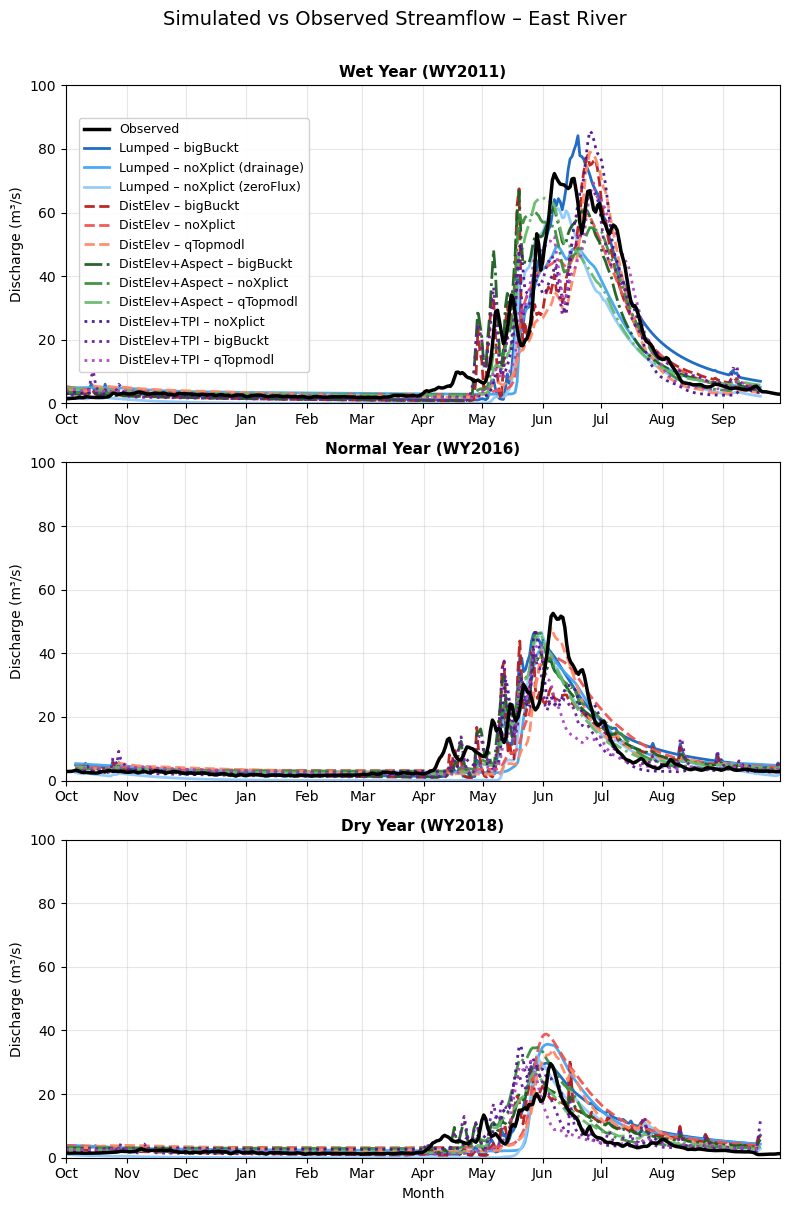

In [115]:
# import mdates
from matplotlib import dates as mdates
model_styles = {
    "lumped": {
        "bigBuckt":          {"color": "#1565C0", "ls": "-",  "label": "Lumped – bigBuckt"},
        "noXplict_drainage": {"color": "#42A5F5", "ls": "-",  "label": "Lumped – noXplict (drainage)"},
        "noXplict_zeroFlux": {"color": "#90CAF9", "ls": "-",  "label": "Lumped – noXplict (zeroFlux)"},
    },
    "distributed_elev": {
        "bigBuckt":          {"color": "#B71C1C", "ls": "--", "label": "DistElev – bigBuckt"},
        "noXplict_drainage": {"color": "#EF5350", "ls": "--", "label": "DistElev – noXplict"},
        "qTopmodl":          {"color": "#FF8A65", "ls": "--", "label": "DistElev – qTopmodl"},
    },
    "distributed_elevAspect": {
        "bigBuckt":          {"color": "#1B5E20", "ls": "-.",  "label": "DistElev+Aspect – bigBuckt"},
        "noXplict_drainage": {"color": "#388E3C", "ls": "-.",  "label": "DistElev+Aspect – noXplict"},
        "qTopmodl":          {"color": "#66BB6A", "ls": "-.",  "label": "DistElev+Aspect – qTopmodl"},
    },
    "distributed_elevTPI": {
        "noXplict_drainage": {"color": "#4A148C", "ls": ":",  "label": "DistElev+TPI – noXplict"},
        "bigBuckt":          {"color": "#6A1B9A", "ls": ":",  "label": "DistElev+TPI – bigBuckt"},
        "qTopmodl":          {"color": "#AB47BC", "ls": ":",  "label": "DistElev+TPI – qTopmodl"},
    }
}

year_periods = [
    ("Wet Year (WY2011)",    WET_WY),
    ("Normal Year (WY2016)", NORMAL_WY),
    ("Dry Year (WY2018)",    DRY_WY),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=False)
fig.suptitle("Simulated vs Observed Streamflow – East River", fontsize=14, y=1.005)

for ax, (title, period) in zip(axes, year_periods):
    obs_slice = obs_streamflow['value'].loc[period.start:period.stop]
    ax.plot(obs_slice.index, obs_slice.values,
            color='black', linewidth=2.5, label='Observed', zorder=10)

    for domain, domain_styles in model_styles.items():
        for model_key, style in domain_styles.items():
            if model_key not in model_discharge.get(domain, {}):
                continue
            if title != "Normal Year (WY2016)":
                shift = -10
            else:
                shift = 5
            q_slice = model_discharge[domain][model_key].loc[period.start:period.stop]
            ax.plot(q_slice.index, q_slice.shift(shift).values,
                    color=style['color'], linestyle=style['ls'],
                    linewidth=2, label=style['label'], alpha=0.95)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp(period.start), pd.Timestamp(period.stop))
    ax.set_ylim(0,100)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.4, 0.92),
           fontsize=9, framealpha=0.9)
axes[-1].set_xlabel("Month", fontsize=10)

plt.tight_layout()
fig.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_streamflow_wet_normal_dry.png', dpi=150, bbox_inches='tight')
plt.show()

In [147]:
import datetime as dt
# runoff metrics
def nse(obs, sim):
    obs_mean = np.mean(obs)
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - obs_mean) ** 2)
    return 1 - (numerator / denominator)
def kge(obs, sim):
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)
    obs_std = np.std(obs)
    sim_std = np.std(sim)
    correlation = np.corrcoef(obs, sim)[0, 1]
    alpha = sim_std / obs_std
    beta = sim_mean / obs_mean
    kge_value = 1 - np.sqrt((correlation - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_value
def log_nse(obs, sim):
    obs_log = np.log(obs + 1e-6)
    sim_log = np.log(sim + 1e-6)
    return nse(obs_log, sim_log)
def com_difference(obs, sim):
    # calculate average center of mass timing difference between obs and sim
    com_differences = []
    for wy in obs.index.year.unique():
        if wy == 2000:
            continue
        time_slice = slice(f"{wy}-10-01", f"{wy+1}-09-30")
        obs_wy = obs.loc[time_slice]
        sim_wy = sim.loc[time_slice]
        if obs_wy.empty or sim_wy.empty or obs_wy.sum() == 0 or sim_wy.sum() == 0:
            continue
        # center of mass timing
        com_obs = obs_wy.cumsum() / obs_wy.sum()
        com_sim = sim_wy.cumsum() / sim_wy.sum()
        above_half_obs = com_obs[com_obs >= 0.5]
        above_half_sim = com_sim[com_sim >= 0.5]
        if above_half_obs.empty or above_half_sim.empty:
            continue
        half_mass_obs = above_half_obs.index[0]   # add 1 day to get the first day above 50%
        half_mass_sim = above_half_sim.index[0] 
        com_differences.append(dt.timedelta(days=(half_mass_sim - half_mass_obs).days))
    mean_com_diff = np.mean(com_differences[1:])
    # convert to pandas timestamp
    mean_com_diff = pd.to_timedelta(mean_com_diff).days
    return mean_com_diff
def volume_normalized_bias(obs, sim):
    volume_bias = np.sum(sim - obs) / np.sum(obs)
    return volume_bias
def jas_volumetric_bias(obs, sim):
    jas_mask = obs.index.month.isin([7, 8, 9])
    obs_jas = obs[jas_mask]
    sim_jas = sim[jas_mask]
    jas_bias = np.sum(sim_jas - obs_jas) / np.sum(obs_jas)  
    return jas_bias

In [148]:
# build table for each model type of these metrics for all years
metric_df = pd.DataFrame(columns=['Domain', 'Model', 'NSE', 'KGE', 'Log NSE', 'COM Difference', 'Volume-Percent Total Bias', 'JAS Volume-Percent Bias'])
count = 0
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        obs = obs_streamflow['value'].loc[sim.index]
        mask = ~obs.isna() & ~sim.isna()
        nse_val = nse(obs[mask], sim[mask])
        kge_val = kge(obs[mask], sim[mask])
        log_nse_val = log_nse(obs[mask], sim[mask])
        com_diff_val = com_difference(obs[mask].iloc[1:], sim[mask].iloc[1:])
        vnb = volume_normalized_bias(obs[mask], sim[mask])
        jas_bias = jas_volumetric_bias(obs[mask], sim[mask])

        tmp_df = pd.DataFrame({
            'Domain': [domain],
            'Model': [model_key],
            'NSE': [nse_val],
            'KGE': [kge_val],
            'Log NSE': [log_nse_val],
            'COM Difference': [com_diff_val],
            'Normalized Volume Bias': [vnb],
            'JAS Volume-Percent Bias': [jas_bias]
        })
        if count == 0:
            metric_df = tmp_df
            count += 1
        else:
            metric_df = pd.concat([metric_df, tmp_df], ignore_index=True)

In [149]:
# get volume percent bias for each year
yearly_bias_df = pd.DataFrame(columns=['Domain', 'Model', 'Year', 'Volume-Percent Total Bias'])
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        for wy in obs_streamflow.index.year.unique():
            if wy < 2001:
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            obs_wy = obs_streamflow['value'].where(mask).loc[time_slice]
            sim_wy = sim.where(mask).loc[time_slice]
            if obs_wy.empty or sim_wy.empty:
                continue
            vptb = volume_normalized_bias(obs_wy, sim_wy)
            yearly_bias_df = pd.concat([yearly_bias_df, pd.DataFrame({
                'Domain': [domain],
                'Model': [model_key],
                'Year': [wy],
                'Normalized Volume Bias': [vptb],
            })], ignore_index=True)

In [150]:
# order by noXplict_zeroFlux, noXplict_drainage, bigBuckt, qTopmodl
yearly_bias_df = yearly_bias_df.sort_values(by=['Domain', 'Model'], key=lambda col: col.map({
    "noXplict_zeroFlux": 0,
    "noXplict_drainage": 1,
    "bigBuckt": 2,
    "qTopmodl": 3
}))

(-0.45, 0.45)

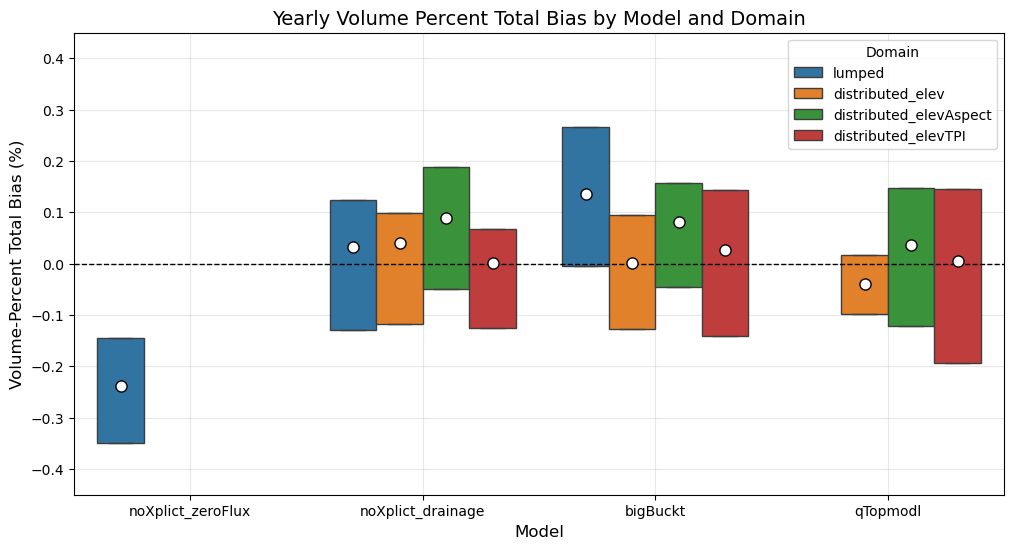

In [151]:
# plot boxplot of each models volume percent bias by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=yearly_bias_df, 
            x='Model', 
            y='Normalized Volume Bias', 
            hue='Domain', showmeans=True,
            medianprops={'linewidth':0},
            meanprops={
                "marker": "o",          # Change shape (e.g., 'o' for circle, 's' for square)
                "markerfacecolor": "white", 
                "markeredgecolor": "black",
                "markersize": "8"
            },
            whis=0,
            showfliers=False,
            )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Yearly Volume Percent Total Bias by Model and Domain", fontsize=14)
plt.ylabel("Volume-Percent Total Bias (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title='Domain')
plt.grid(True, alpha=0.3)
plt.ylim(-0.45, 0.45)

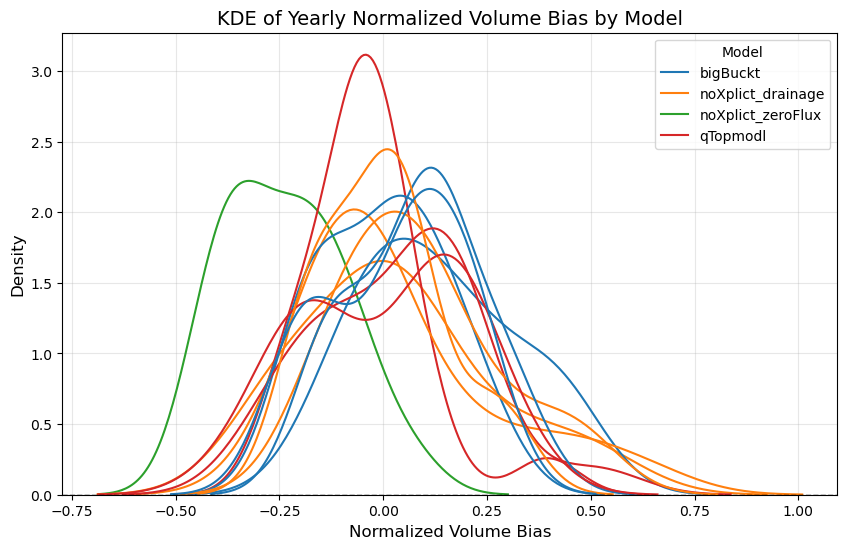

In [152]:
# create pdf of normal total flow bias, only show kde for all model types, make linestyle differentfor each domain
plt.figure(figsize=(10, 6))
for domain in yearly_bias_df['Domain'].unique():
    domain_data = yearly_bias_df[yearly_bias_df['Domain'] == domain]
    sns.kdeplot(data=domain_data, x='Normalized Volume Bias', hue='Model', fill=False, common_norm=False, alpha=1.0, linestyle='-',
                hue_order=['bigBuckt', 'noXplict_drainage', 'noXplict_zeroFlux', 'qTopmodl'])
plt.title("KDE of Yearly Normalized Volume Bias by Model", fontsize=14)
plt.xlabel("Normalized Volume Bias", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

/tmp/ipykernel_1285325/2912748552.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


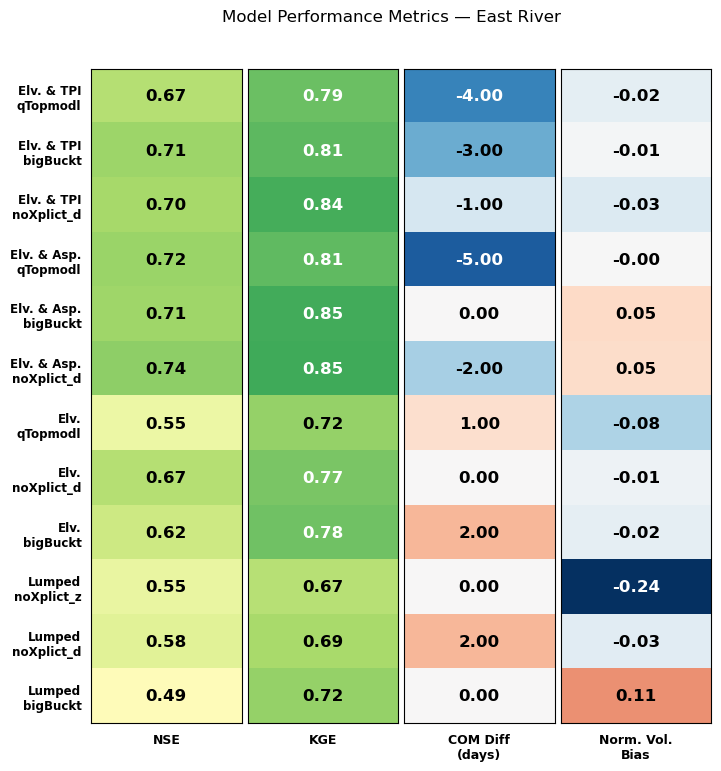

In [234]:

# --- Plot 1: per-column heatmap (visual table) ---
import matplotlib.colors as mcolors

domain_short = {
    'lumped': 'Lumped',
    'distributed_elev': 'Elv.',
    'distributed_elevAspect': 'Elv. & Asp.',
    'distributed_elevTPI': 'Elv. & TPI',
}
model_short = {
    'noXplict_zeroFlux': 'noXplict_z',
    'noXplict_drainage': 'noXplict_d',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
row_labels = [
    f"{domain_short[d]}\n{model_short[m]}"
    for d, m in zip(metric_df['Domain'], metric_df['Model'])
]

metrics_hmap = [
    ('NSE',                     'RdYlGn', False),
    ('KGE',                     'RdYlGn', False),
    ('COM Difference',          'RdBu_r',  True),
    ('Normalized Volume Bias',  'RdBu_r',  True),
]
col_display = ['NSE', 'KGE', 'COM Diff\n(days)', 'Norm. Vol.\nBias']

fig, axes = plt.subplots(1, 4, figsize=(8, 8.5), sharey=True,
                         gridspec_kw={'wspace': 0.04})

for ax, (col, cmap, diverging), xlabel in zip(axes, metrics_hmap, col_display):
    vals = metric_df[col].values[::-1]
    data = vals.reshape(-1, 1)

    if diverging:
        if col == 'COM Difference':
            offset = 4
        else: offset = 0.1
        absmax = max(abs(vals.min()), abs(vals.max())+offset, 1e-9)
        norm = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    else:
        norm = mcolors.Normalize(vmin=min(vals.min(), 0), vmax=1.0)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

    for i, v in enumerate(vals):
        brightness = norm(v)
        txt_color = 'white' if (brightness < 0.25 or brightness > 0.75) else 'black'
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                fontsize=12, color=txt_color, fontweight='bold')

    ax.set_xticks([0])
    ax.set_xticklabels([xlabel], rotation=0, ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(left=False, bottom=False)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(ax.get_yticks(), fontweight='bold')

axes[0].set_yticklabels(row_labels[::-1], fontsize=8.5)
# for ax in axes[1:]:
#     ax.set_yticklabels([])

fig.suptitle("Model Performance Metrics — East River", fontsize=12, y=0.95)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()


7 [-0.3908384  -0.65119063]
9 [-0.46345862 -0.7496527 ]
7 [-0.99736798  0.32656995]
9 [ 0.39738627 -0.89905202]
7 [ 0.04268626 -0.76368042]
9 [-0.3099032   0.36850568]
7 [-0.07602209 -0.32890784]
9 [ 0.25632355 -0.85984331]


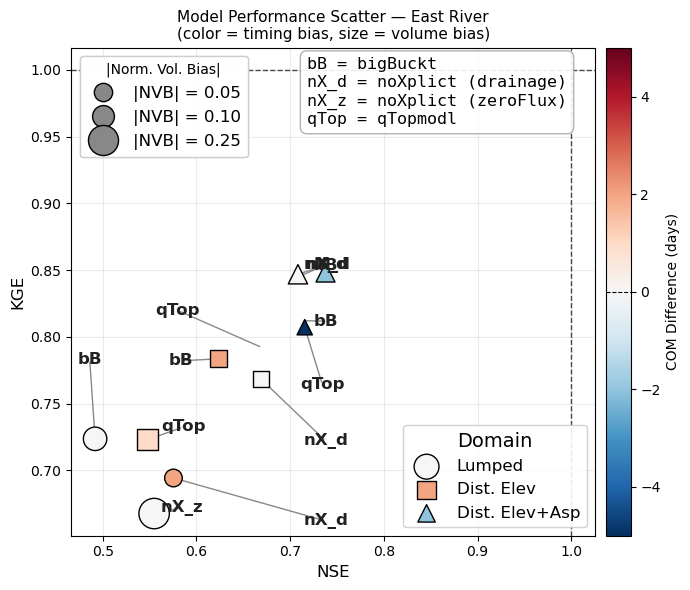

In [154]:

# --- Plot 2: performance scatter (Taylor-diagram-like) ---
from matplotlib.lines import Line2D
from adjustText import adjust_text

domain_markers = {
    'lumped':                 ('o', 'Lumped'),
    'distributed_elev':       ('s', 'Dist. Elev'),
    'distributed_elevAspect': ('^', 'Dist. Elev+Asp'),
}
model_abbrev = {
    'bigBuckt':          'bB',
    'noXplict_drainage': 'nX_d',
    'noXplict_zeroFlux': 'nX_z',
    'qTopmodl':          'qTop',
}
model_fullname = {
    'bB':    'bigBuckt',
    'nX_d':  'noXplict (drainage)',
    'nX_z':  'noXplict (zeroFlux)',
    'qTop':  'qTopmodl',
}

com  = metric_df['COM Difference'].values
nvb  = metric_df['Normalized Volume Bias'].values
nse_ = metric_df['NSE'].values
kge_ = metric_df['KGE'].values

absmax_com = max(abs(com.min()), abs(com.max()), 1)
com_norm   = mcolors.TwoSlopeNorm(vmin=-absmax_com, vcenter=0, vmax=absmax_com)
cmap_com   = plt.cm.RdBu_r

nvb_abs = np.abs(nvb)
sizes   = 120 + 360 * (nvb_abs / nvb_abs.max())

fig, ax = plt.subplots(figsize=(7, 6))

for domain, (marker, dlabel) in domain_markers.items():
    mask = (metric_df['Domain'] == domain).values
    ax.scatter(
        nse_[mask], kge_[mask],
        c=com[mask], cmap=cmap_com, norm=com_norm,
        s=sizes[mask], marker=marker,
        edgecolors='k', linewidths=1.0, zorder=5,
        label=dlabel,
    )

sm = plt.cm.ScalarMappable(cmap=cmap_com, norm=com_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label('COM Difference (days)', fontsize=10)
cbar.ax.axhline(0, color='k', lw=0.8, ls='--')

texts = []
for _, row in metric_df.iterrows():
    t = ax.annotate(
        model_abbrev[row['Model']],
        (row['NSE'], row['KGE']),
        fontsize=12, color='#222222', fontweight='bold',
        zorder=10,
    )
    texts.append(t)

adjust_text(
    texts, ax=ax, expand=(6.4, 6.7), ha='left', va='top',
    arrowprops=dict(arrowstyle='-', color='#888888', lw=1),
);

# domain legend (lower right)
domain_legend = ax.legend(title='Domain', fontsize=12, loc='lower right', framealpha=0.9, title_fontsize=14)
ax.add_artist(domain_legend);

# size legend for |NVB| (upper left)
nvb_refs  = [0.05, 0.10, 0.25]
size_refs = [100 + 360 * (v / nvb_abs.max()) for v in nvb_refs]
size_handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           color='w', markerfacecolor='#888888', markeredgecolor='k',
           markersize=np.sqrt(s), label=f'|NVB| = {v:.2f}')
    for v, s in zip(nvb_refs, size_refs)
]
size_legend = ax.legend(handles=size_handles, title='|Norm. Vol. Bias|',
                        fontsize=12, loc='upper left', framealpha=0.9)
ax.add_artist(size_legend)

# model abbreviation key (upper right, plain text box)
abbrev_lines = '\n'.join(f'{k} = {v}' for k, v in model_fullname.items())
ax.text(
    0.45, 0.98, abbrev_lines,
    transform=ax.transAxes,
    fontsize=12, va='top', ha='left', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#aaaaaa', alpha=0.9),
)

ax.axhline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.axvline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.set_xlabel('NSE', fontsize=12)
ax.set_ylabel('KGE', fontsize=12)
ax.set_title('Model Performance Scatter — East River\n'
             '(color = timing bias, size = volume bias)', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()


# SWE - Q Relationships

In [170]:
# get snotel data
snotel_df = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "snotel_swe.csv", parse_dates=['date'], index_col='date')
snotel_apr1_swe = snotel_df[(snotel_df.index.month == 4) & (snotel_df.index.day == 1)]
snotel_apr1_swe.index = snotel_apr1_swe.index.year
annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)
annual_q.index = annual_q.index.year+1
# SWE-Q runoff regression
swe_q_df = pd.DataFrame({
    'apr1_swe': snotel_apr1_swe['value'],
    'annual_q': annual_q['value']
})



/tmp/ipykernel_1285325/2094612696.py:5: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)


In [171]:
# get mean, daily scalarSWE from each model
swe_daily_dict = {}
for domain, models in model_discharge.items():
    # hru area
    
    for model_key, sim in models.items():
        filepath = model_files[domain][model_key]
        hru_area = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarSWE' in ds.data_vars:
            swe_var = (ds['scalarSWE']*hru_area).sum(dim='hru')/area_m2
            # for each year, get 1 Apr SWE
            swe_apr1 = []
            wys = []
            for wy in sim.index.year.unique():
                if (wy < 2001) or (wy > 2021):
                    continue
                wys.append(wy)
                time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
                swe_wy = swe_var.sel(time=time_slice)
                # get 1 Apr value
                apr1 = pd.Timestamp(f"{wy}-04-01")
                if apr1 in swe_wy.time.values:
                    swe_apr1.append(float(swe_wy.sel(time=apr1).values))
                else:
                    # if no exact match, interpolate
                    swe_apr1.append(float(swe_wy.interp(time=apr1).values))
            swe_daily_dict[(domain, model_key)] = pd.DataFrame({
                'apr1_swe': swe_apr1,
            }, index=wys)



In [175]:
# calculate water year annual q for each model
annual_q_dict = {}
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        wy_q = []
        wys = []
        for wy in sim.index.year.unique():
            if (wy < 2002) or (wy > 2021):
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            sim_wy = sim.loc[time_slice]
            annual_q = sim_wy.sum()
            wy_q.append(annual_q)
            wys.append(wy)

        annual_q_dict[(domain, model_key)] = pd.DataFrame({
            'annual_q': wy_q,
        }, index=wys)

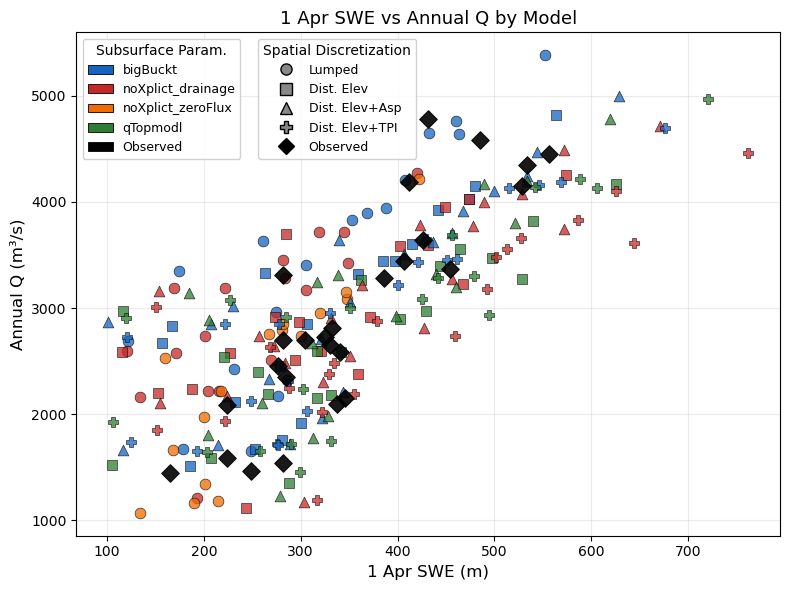

In [178]:
# scatter plot of 1 Apr SWE vs annual Q — color = model type, shape = domain
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_colors = {
    'bigBuckt':          '#1565C0',
    'noXplict_drainage': '#C62828',
    'noXplict_zeroFlux': '#EF6C00',
    'qTopmodl':          '#2E7D32',
}
domain_markers = {
    'lumped':                 'o',
    'distributed_elev':       's',
    'distributed_elevAspect': '^',
    'distributed_elevTPI':    'P',
}
domain_labels = {
    'lumped':                 'Lumped',
    'distributed_elev':       'Dist. Elev',
    'distributed_elevAspect': 'Dist. Elev+Asp',
    'distributed_elevTPI':    'Dist. Elev+TPI',
}

fig, ax = plt.subplots(figsize=(8, 6))

for (domain, model_key), swe_df in swe_daily_dict.items():
    annual_q = annual_q_dict[(domain, model_key)]
    merged_df = swe_df.merge(annual_q, left_index=True, right_index=True)
    merged_df = merged_df[merged_df['apr1_swe']>100]
    ax.scatter(
        merged_df['apr1_swe'], merged_df['annual_q'],
        color=model_colors[model_key],
        marker=domain_markers[domain],
        alpha=0.75, edgecolors='k', linewidths=0.5, s=60, zorder=4,
    )

# observed
ax.scatter(
    swe_q_df['apr1_swe'], swe_q_df['annual_q'],
    color='black', marker='D', s=80, edgecolors='k', linewidths=0.8,
    alpha=0.9, zorder=5,
)

# color legend — model type (upper left)
model_keys_present = {mk for _, mk in swe_daily_dict.keys()}
color_handles = [
    Patch(facecolor=c, edgecolor='k', linewidth=0.6, label=m)
    for m, c in model_colors.items() if m in model_keys_present
]
color_handles.append(Patch(facecolor='black', edgecolor='k', linewidth=0.6, label='Observed'))
color_legend = ax.legend(handles=color_handles, title='Subsurface Param.',
                         fontsize=9, loc='upper left', framealpha=0.9)
ax.add_artist(color_legend)

# shape legend — domain (lower right)
domains_present = {d for d, _ in swe_daily_dict.keys()}
shape_handles = [
    Line2D([0], [0], marker=m, linestyle='None', color='w',
           markerfacecolor='#888888', markeredgecolor='k',
           markersize=8, label=domain_labels[d])
    for d, m in domain_markers.items() if d in domains_present
]
shape_handles.append(
    Line2D([0], [0], marker='D', linestyle='None', color='w',
           markerfacecolor='black', markeredgecolor='k',
           markersize=8, label='Observed')
)
ax.legend(handles=shape_handles, title='Spatial Discretization', fontsize=9,
          loc='upper left', framealpha=0.9, bbox_to_anchor=(0.25, 1))

ax.set_xlabel('1 Apr SWE (m)', fontsize=12)
ax.set_ylabel('Annual Q (m³/s)', fontsize=12)
ax.set_title('1 Apr SWE vs Annual Q by Model', fontsize=13)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [179]:
# SWE-Q regressions for each model type
from sklearn.linear_model import LinearRegression
regression_results = []
for (domain, model_key), swe_df in swe_daily_dict.items():
    annual_q = annual_q_dict[(domain, model_key)]
    merged_df = swe_df.merge(annual_q, left_index=True, right_index=True).dropna()
    merged_df = merged_df[(merged_df['apr1_swe'] >= 150) & (merged_df['annual_q'] >= 0)]
    X = merged_df['apr1_swe'].values.reshape(-1, 1)
    y = merged_df['annual_q'].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    regression_results.append({
        'Domain': domain,
        'Model': model_key,
        'Slope': reg.coef_[0],
        'Intercept': reg.intercept_,
        'R²': r2,
    })
obs_regression = LinearRegression().fit(swe_q_df.dropna()['apr1_swe'].values.reshape(-1, 1), swe_q_df.dropna()['annual_q'].values)
regression_results.append({
    'Domain': 'Observed',
    'Model': 'Observed',
    'Slope': obs_regression.coef_[0],
    'Intercept': obs_regression.intercept_,
    'R²': obs_regression.score(swe_q_df.dropna()['apr1_swe'].values.reshape(-1, 1), swe_q_df.dropna()['annual_q'].values),
})
regression_results

[{'Domain': 'lumped',
  'Model': 'bigBuckt',
  'Slope': np.float64(9.09432213940839),
  'Intercept': np.float64(435.2394195715401),
  'R²': 0.7501378188982566},
 {'Domain': 'lumped',
  'Model': 'noXplict_drainage',
  'Slope': np.float64(7.587565000971112),
  'Intercept': np.float64(994.0045948529548),
  'R²': 0.5530947768753016},
 {'Domain': 'lumped',
  'Model': 'noXplict_zeroFlux',
  'Slope': np.float64(9.515883032484508),
  'Intercept': np.float64(-43.32773088451631),
  'R²': 0.7299946287691736},
 {'Domain': 'distributed_elev',
  'Model': 'bigBuckt',
  'Slope': np.float64(6.775511339925628),
  'Intercept': np.float64(756.4136712338527),
  'R²': 0.6812882350865922},
 {'Domain': 'distributed_elev',
  'Model': 'noXplict_drainage',
  'Slope': np.float64(5.499633622727742),
  'Intercept': np.float64(1098.8098531090488),
  'R²': 0.5938449156668739},
 {'Domain': 'distributed_elev',
  'Model': 'qTopmodl',
  'Slope': np.float64(5.607986396922144),
  'Intercept': np.float64(671.1129091579819),

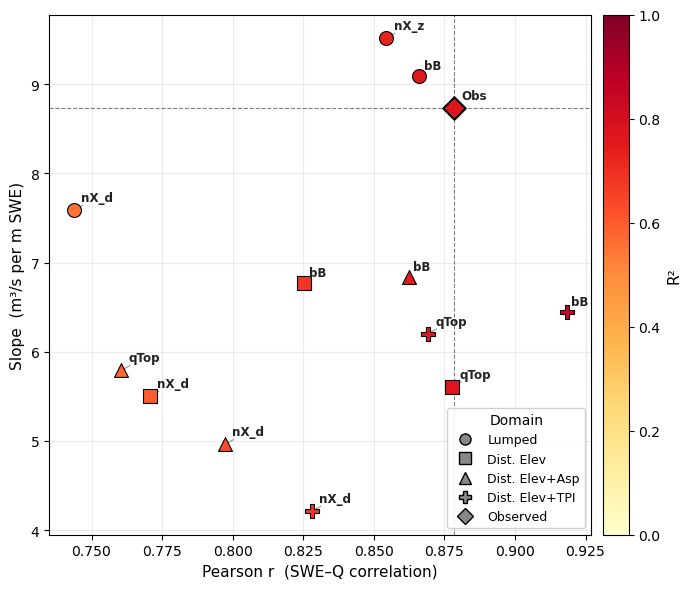

In [180]:
# SWE-Q regression diagnostic scatter
# x = Pearson r, y = slope (sensitivity), color = R²
# shape = domain, observed shown as black diamond

reg_df = pd.DataFrame(regression_results)
reg_df['r'] = np.sqrt(reg_df['R²'])   # r = sqrt(R²) for positive-slope OLS

domain_markers_reg = {
    
    'lumped':                 'o',
    'distributed_elev':       's',
    'distributed_elevAspect': '^',
    'distributed_elevTPI':    'P',
    'Observed':               'D',
}
domain_labels_reg = {
    'lumped':                 'Lumped',
    'distributed_elev':       'Dist. Elev',
    'distributed_elevAspect': 'Dist. Elev+Asp',
    'distributed_elevTPI':    'Dist. Elev+TPI',
    'Observed':               'Observed',
}
model_abbrev_reg = {
    'bigBuckt':          'bB',
    'noXplict_drainage': 'nX_d',
    'noXplict_zeroFlux': 'nX_z',
    'qTopmodl':          'qTop',
    'Observed':          'Obs',
}

r2_vals    = reg_df['R²'].values
slope_vals = reg_df['Slope'].values
r2_norm    = mcolors.Normalize(vmin=0, vmax=1)
cmap_r2    = plt.cm.YlOrRd

fig, ax = plt.subplots(figsize=(7, 6))

# model points
for _, row in reg_df[reg_df['Domain'] != 'Observed'].iterrows():
    ax.scatter(
        row['r'], row['Slope'],
        c=[cmap_r2(r2_norm(row['R²']))],
        marker=domain_markers_reg[row['Domain']],
        s=100, edgecolors='k', linewidths=0.8, zorder=5,
    )

# observed — always black diamond, still colored by R²
obs_row = reg_df[reg_df['Domain'] == 'Observed'].iloc[0]
ax.scatter(
    obs_row['r'], obs_row['Slope'],
    c=[cmap_r2(r2_norm(obs_row['R²']))],
    marker='D', s=130, edgecolors='k', linewidths=1.5, zorder=6,
)

# colorbar for R²
sm = plt.cm.ScalarMappable(cmap=cmap_r2, norm=r2_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label('R²', fontsize=11)

# labels
texts = []
for _, row in reg_df.iterrows():
    t = ax.annotate(
        model_abbrev_reg.get(row['Model'], row['Model']),
        (row['r'], row['Slope']),
        fontsize=8.5, fontweight='bold', color='#222222', zorder=10,
    )
    texts.append(t)
adjust_text(texts, ax=ax, expand=(1.4, 1.6),
            arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7))

# observed reference lines
ax.axhline(obs_row['Slope'], color='k', ls='--', lw=0.8, alpha=0.5, label='_')
ax.axvline(obs_row['r'],     color='k', ls='--', lw=0.8, alpha=0.5, label='_')

# shape legend
domains_in_reg = set(reg_df['Domain'].unique())
shape_handles = [
    Line2D([0],[0], marker=domain_markers_reg[d], linestyle='None', color='w',
           markerfacecolor='#888888', markeredgecolor='k',
           markersize=8, label=domain_labels_reg[d])
    for d in domain_markers_reg if d in domains_in_reg
]
ax.legend(handles=shape_handles, title='Domain', fontsize=9,
          loc='lower right', framealpha=0.9)

ax.set_xlabel('Pearson r  (SWE–Q correlation)', fontsize=11)
ax.set_ylabel('Slope  (m³/s per m SWE)', fontsize=11)
# ax.set_title('SWE–Q Regression by Model', color = R², dashed lines = observed reference)', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
# plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_sweQ_regression_scatter.png',
#             dpi=150, bbox_inches='tight')
plt.show()

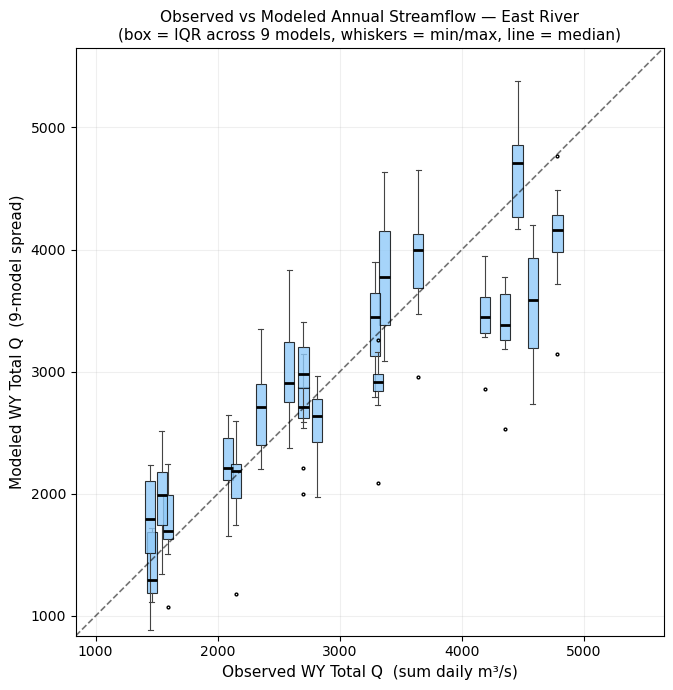

In [181]:
# Boxplot: for each WY, show spread of 9 modeled Q values
# box positioned at observed Q on x-axis, y centered on median

obs_wy_totals = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_wy_totals[wy] = obs_wy.sum()
obs_wy_series = pd.Series(obs_wy_totals)

box_positions, box_data, box_years = [], [], []
for wy, obs_q in sorted(obs_wy_series.items()):
    model_vals = [
        sim_df.loc[wy, 'annual_q']
        for (_, _), sim_df in annual_q_dict.items()
        if wy in sim_df.index
    ]
    if model_vals:
        box_positions.append(obs_q)
        box_data.append(model_vals)
        box_years.append(wy)

q_range   = max(box_positions) - min(box_positions)
box_width = q_range * 0.025

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=box_width,
    patch_artist=True,
    vert=True,
    manage_ticks=False,
    medianprops=dict(color='black',    linewidth=2.0),
    boxprops=dict(facecolor='#90CAF9', alpha=0.8, linewidth=0.8),
    whiskerprops=dict(linewidth=0.8,   color='#444'),
    capprops=dict(linewidth=0.8,       color='#444'),
    flierprops=dict(marker='.', markersize=4, color='#666'),
)

# annotate each box with the water year at the median


# 1:1 line
all_sim_flat = np.concatenate(box_data)
lim_lo = min(min(box_positions), all_sim_flat.min()) * 0.95
lim_hi = max(max(box_positions), all_sim_flat.max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal')

ax.set_xlabel('Observed WY Total Q  (sum daily m³/s)', fontsize=11)
ax.set_ylabel('Modeled WY Total Q  (9-model spread)', fontsize=11)
ax.set_title('Observed vs Modeled Annual Streamflow — East River\n'
             '(box = IQR across 9 models, whiskers = min/max, line = median)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_obs_vs_sim_annual_Q_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

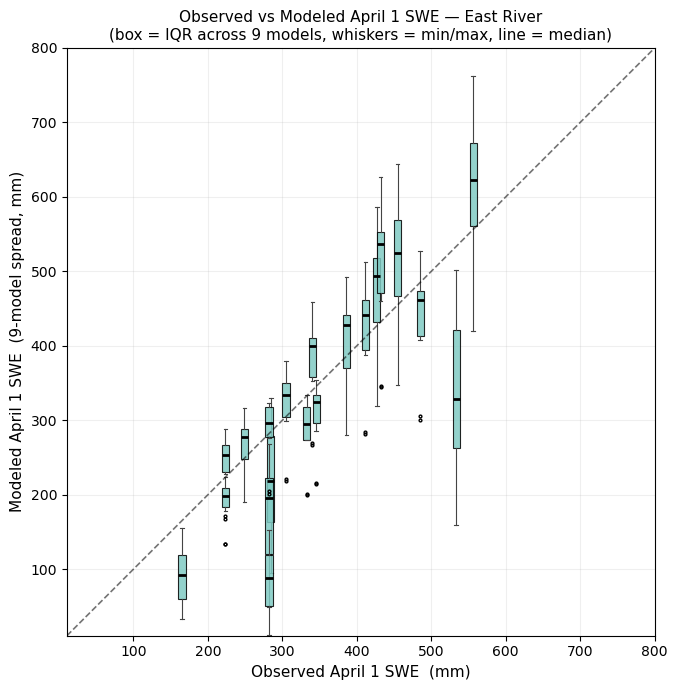

In [182]:
# Boxplot: April 1 SWE observed vs modeled (9-model spread per year)
# observed = SNOTEL (mm), modeled scalarSWE converted m→mm
# years with observed Apr1 SWE < 100 mm excluded

obs_apr1 = snotel_apr1_swe['value'].copy()   # mm, indexed by year
obs_apr1 = obs_apr1[obs_apr1 >= 100]

box_positions, box_data, box_years = [], [], []
for wy, obs_swe in sorted(obs_apr1.items()):
    if wy < 2002 or wy > 2021:
        continue
    model_vals = [
        swe_df.loc[wy, 'apr1_swe']   # m → mm
        for (_, _), swe_df in swe_daily_dict.items()
        if wy in swe_df.index
    ]
    if model_vals:
        box_positions.append(obs_swe)
        box_data.append(model_vals)
        box_years.append(wy)

q_range   = max(box_positions) - min(box_positions)
box_width = q_range * 0.025

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=box_width,
    patch_artist=True,
    vert=True,
    manage_ticks=False,
    medianprops=dict(color='black',    linewidth=2.0),
    boxprops=dict(facecolor='#80CBC4', alpha=0.85, linewidth=0.8),
    whiskerprops=dict(linewidth=0.8,   color='#444'),
    capprops=dict(linewidth=0.8,       color='#444'),
    flierprops=dict(marker='.', markersize=4, color='#666'),
)

all_sim_flat = np.concatenate(box_data)
lim_lo = min(min(box_positions), all_sim_flat.min()) * 0.9
lim_hi = max(max(box_positions), all_sim_flat.max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal')

ax.set_xlabel('Observed April 1 SWE  (mm)', fontsize=11)
ax.set_ylabel('Modeled April 1 SWE  (9-model spread, mm)', fontsize=11)
ax.set_title('Observed vs Modeled April 1 SWE — East River\n'
             '(box = IQR across 9 models, whiskers = min/max, line = median)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_obs_vs_sim_apr1SWE_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

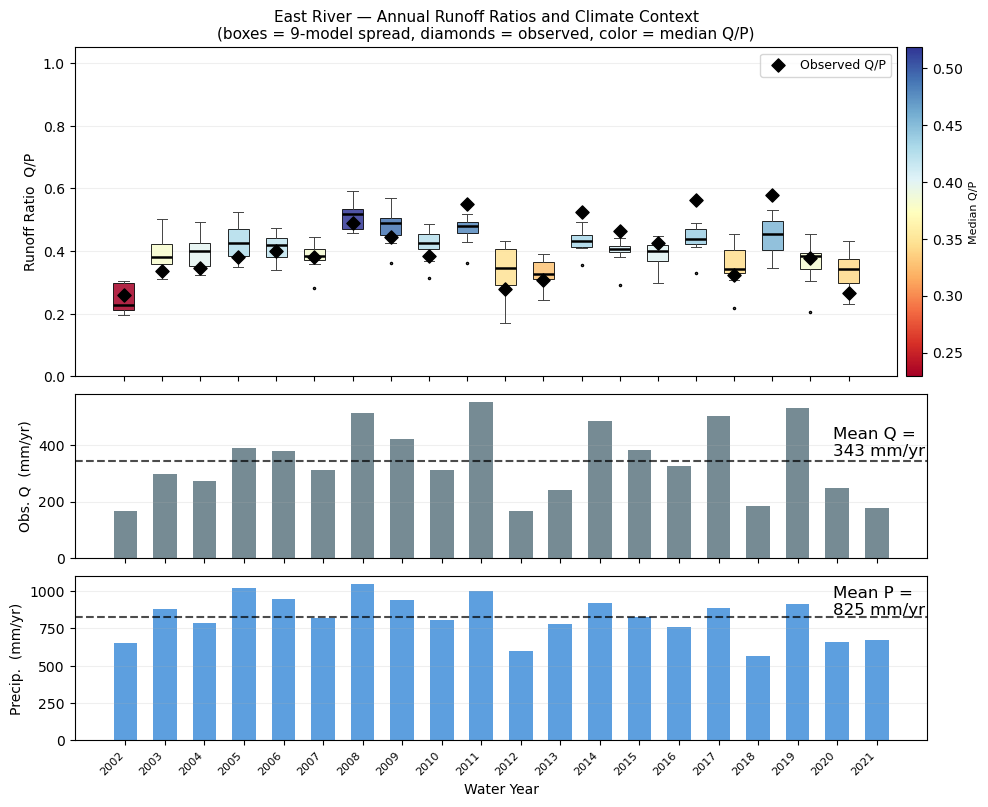

In [183]:
# Runoff ratio (Q/P) by water year
# Q converted to depth (mm/yr), P from pptrate (kg m-2 s-1 -> mm/yr)
# Three panels: Q/P boxplot (models) | observed Q | annual P
# Boxes colored by median Q/P value

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day

precip_wy = {}
for wy in range(2002, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model, aligned to same domain area ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# --- Color boxes by median RR (low=dry orange, high=wet blue) ---
medians     = np.array([np.median(d) for d in rr_box_data])
rr_norm     = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
rr_cmap     = cm.RdYlBu
box_colors  = [rr_cmap(rr_norm(m)) for m in medians]

# --- Figure: 3 panels sharing x-axis ---
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [2, 1, 1]})

# --- Panel 1: Q/P boxplots ---
ax1 = axes[0]
x = np.arange(len(rr_years))
for i, (data, color) in enumerate(zip(rr_box_data, box_colors)):
    bp = ax1.boxplot(
        data, positions=[x[i]], widths=0.55,
        patch_artist=True, vert=True, manage_ticks=False,
        medianprops=dict(color='black', linewidth=1.8),
        boxprops=dict(facecolor=color, alpha=0.85, linewidth=0.7),
        whiskerprops=dict(linewidth=0.7, color='#444'),
        capprops=dict(linewidth=0.7, color='#444'),
        flierprops=dict(marker='.', markersize=3, color='#777'),
    )

# observed Q/P overlay
obs_x = [x[rr_years.index(wy)] for wy in obs_rr.index if wy in rr_years]
ax1.scatter(obs_x, obs_rr.loc[[wy for wy in obs_rr.index if wy in rr_years]],
            color='black', marker='D', s=45, zorder=6, label='Observed Q/P')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylabel('Runoff Ratio  Q/P', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.2, axis='y')

# colorbar for Q/P value
sm = cm.ScalarMappable(cmap=rr_cmap, norm=rr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, pad=0.01, fraction=0.025, aspect=20)
cbar.set_label('Median Q/P', fontsize=8)

# --- Panel 2: Observed Q (mm/yr) ---
ax2 = axes[1]
ax2.bar(x, obs_q_mm.loc[rr_years].values, color='#546E7A', alpha=0.8, width=0.6)
# plot the mean as a horizontal line
mean_q = obs_q_mm.loc[rr_years].mean()
ax2.axhline(y=mean_q, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# annotate the line 
ax2.text(x[-1]-1.1, mean_q+65, f'Mean Q =\n{mean_q:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax2.set_ylabel('Obs. Q  (mm/yr)', fontsize=10)
ax2.grid(True, alpha=0.2, axis='y')

# --- Panel 3: Annual precipitation (mm/yr) ---
ax3 = axes[2]
ax3.bar(x, precip_series.loc[rr_years].values, color='#1976D2', alpha=0.7, width=0.6)
# plot the mean as a horizontal line
mean_p = precip_series.loc[rr_years].mean()
ax3.axhline(y=mean_p, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.text(x[-1]-1.1, mean_p+105, f'Mean P =\n{mean_p:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax3.set_ylabel('Precip.  (mm/yr)', fontsize=10)
ax3.grid(True, alpha=0.2, axis='y')

ax3.set_xticks(x)
ax3.set_xticklabels(rr_years, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Water Year', fontsize=10)

axes[0].set_title('East River — Annual Runoff Ratios and Climate Context\n'
                  '(boxes = 9-model spread, diamonds = observed, color = median Q/P)',
                  fontsize=11)

plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [220]:
# 1990-2010 SWE-Q regression slope = 0.97, intercept = 6.98
q_from_swe = obs_apr1 * 0.97 + 6.98


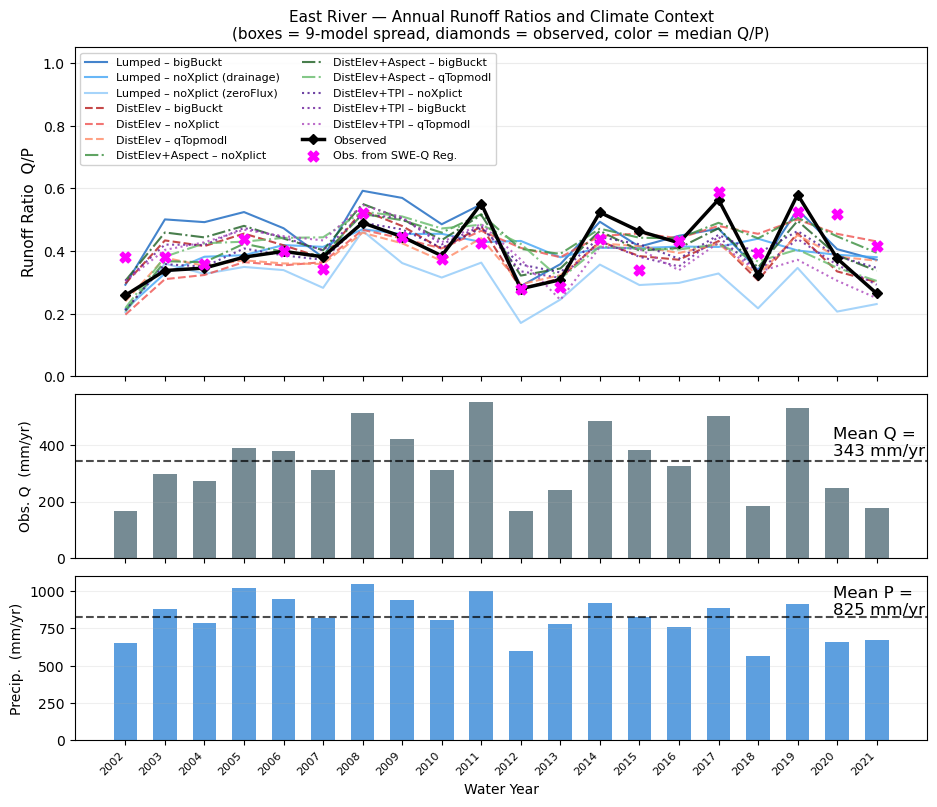

In [223]:
# Runoff ratio (Q/P) by water year
# Q converted to depth (mm/yr), P from pptrate (kg m-2 s-1 -> mm/yr)
# Three panels: Q/P boxplot (models) | observed Q | annual P
# Boxes colored by median Q/P value

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day
x = np.arange(2002, 2022)

precip_wy = {}
for wy in range(2002, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model, aligned to same domain area ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# SWE-Q regression runoff ratio
obs_q_from_swe = obs_apr1 * 0.97 + 6.98
obs_rr_from_swe = obs_q_from_swe / precip_series
obs_rr_from_swe = obs_rr_from_swe.dropna()

# --- Color boxes by median RR (low=dry orange, high=wet blue) ---
medians     = np.array([np.median(d) for d in rr_box_data])
rr_norm     = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
rr_cmap     = cm.RdYlBu
box_colors  = [rr_cmap(rr_norm(m)) for m in medians]

# --- Figure: 3 panels sharing x-axis ---
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [2, 1, 1]})

# --- Panel 1: Q/P spaghetti plot ---
ax = axes[0]
for (domain, model_key), sim_df in annual_q_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    area = domain_areas[domain]
    rr_vals = {
        wy: (sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000) / precip_series[wy]
        for wy in sim_df.index
        if wy in precip_series.index and precip_series[wy] > 0
    }
    rr_s = pd.Series(rr_vals).sort_index()
    ax.plot(x, rr_s.values,
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])

ax.plot(x, obs_rr.values,
        color='black', linewidth=2.5, marker='D', markersize=5,
        zorder=10, label='Observed')

ax.scatter(x, obs_rr_from_swe.values,
           color='magenta', marker='X', s=60, zorder=11, label='Obs. from SWE-Q Reg.')

ax.set_ylabel('Runoff Ratio  Q/P', fontsize=11)
ax.set_title('East River — Annual Runoff Ratio by Model', fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25, axis='y')
ax.legend(fontsize=8, ncol=2, loc='upper left', framealpha=0.9)

# --- Panel 2: Observed Q (mm/yr) ---
ax2 = axes[1]
ax2.bar(x, obs_q_mm.loc[rr_years].values, color='#546E7A', alpha=0.8, width=0.6)
# plot the mean as a horizontal line
mean_q = obs_q_mm.loc[rr_years].mean()
ax2.axhline(y=mean_q, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# annotate the line 
ax2.text(x[-1]-1.1, mean_q+65, f'Mean Q =\n{mean_q:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax2.set_ylabel('Obs. Q  (mm/yr)', fontsize=10)
ax2.grid(True, alpha=0.2, axis='y')

# --- Panel 3: Annual precipitation (mm/yr) ---
ax3 = axes[2]
ax3.bar(x, precip_series.loc[rr_years].values, color='#1976D2', alpha=0.7, width=0.6)
# plot the mean as a horizontal line
mean_p = precip_series.loc[rr_years].mean()
ax3.axhline(y=mean_p, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.text(x[-1]-1.1, mean_p+105, f'Mean P =\n{mean_p:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax3.set_ylabel('Precip.  (mm/yr)', fontsize=10)
ax3.grid(True, alpha=0.2, axis='y')

ax3.set_xticks(x)
ax3.set_xticklabels(rr_years, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Water Year', fontsize=10)

axes[0].set_title('East River — Annual Runoff Ratios and Climate Context\n'
                  '(boxes = 9-model spread, diamonds = observed, color = median Q/P)',
                  fontsize=11)

plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Convert this to a spaghetti plot

# Compare Subsurface States
- compare elevation bands with basin__ColumnOutflow
- scalarTotalSoiLiq
- scalarAquiferRecharge
- scalarAquiferBaseflow
- scalarSoilBaseflow
- October 1 Soil moisture

Text(0.5, 1.0, 'East River — October 1 Soil Moisture by Model\n(scalarTotalSoilLiq, normalized)')

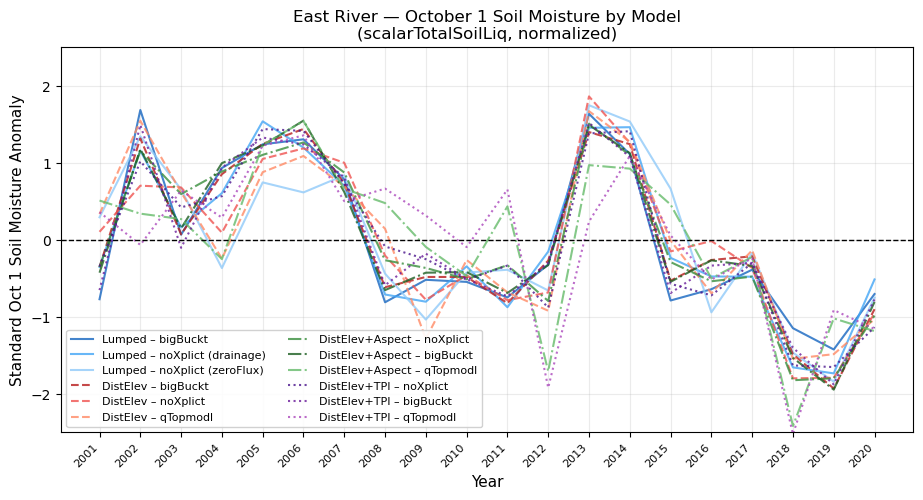

In [185]:
# plot October 1 soil moisture across models as spaghetti plot using scalarTotalSoiLiq
october_1_dates = pd.date_range(start='2001-09-30', end='2021-09-30', freq='YS-OCT')
fig, ax = plt.subplots(figsize=(11, 5))

for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalSoilLiq' not in ds.data_vars:
        continue
    soil_liq = ds['scalarTotalSoilLiq'].mean(dim='hru').resample(time='1D').mean().squeeze()  # mm
    soi_liq_oct1 = []
    for date in october_1_dates:
        if date in soil_liq.time.values:
            soi_liq_oct1.append(float(soil_liq.sel(time=date).values))
        else:
            soi_liq_oct1.append(float(soil_liq.interp(time=date).values))
    soi_liq_s = pd.Series(soi_liq_oct1, index=october_1_dates.year)
    # normalize by the mean of each model
    soi_liq_s = (soi_liq_s - soi_liq_s.mean()) / soi_liq_s.std()
    ax.plot(soi_liq_s.index, soi_liq_s.values,
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
plt.axhline(0, color='k', ls='--', lw=1.0, alpha=1.0)
plt.xticks(october_1_dates.year, rotation=45, ha='right', fontsize=8)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Standard Oct 1 Soil Moisture Anomaly', fontsize=11)
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, ncol=2, loc='lower left', framealpha=0.9)
plt.ylim(-2.5, 2.5)
plt.title('East River — October 1 Soil Moisture by Model\n'
          '(scalarTotalSoilLiq, normalized)', fontsize=12)



# Compare ET States
- compare ET variability by model type?
  
# Compare Soil Moisture
- by plot type, show variability of Oct 1 soil moisture for each model set up and each parameterization

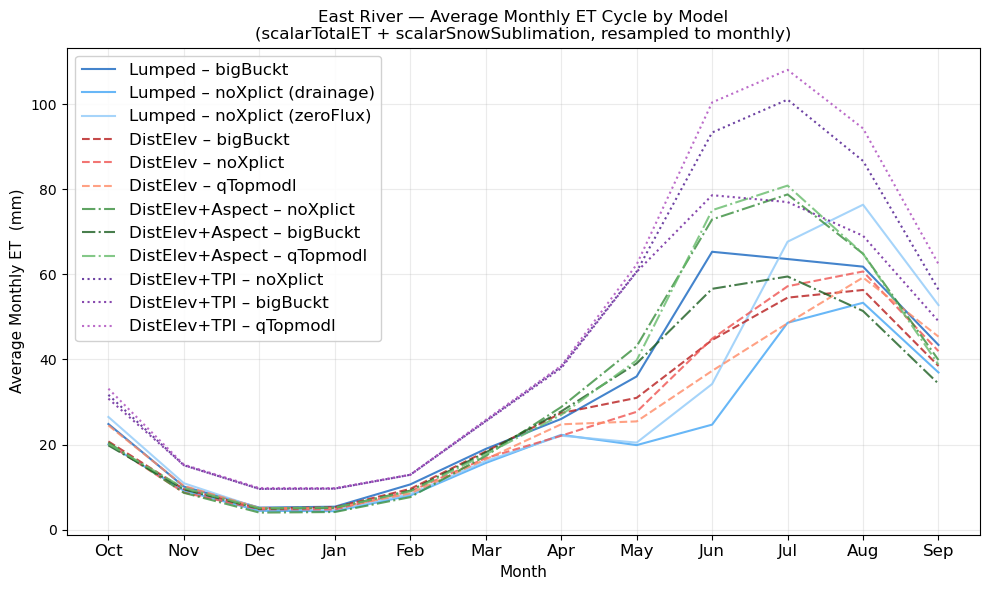

In [186]:
# plot average monthly ET cycle across all models. 
fig, ax = plt.subplots(figsize=(10, 6))
for (domain, model_key), sim_df in annual_q_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalET' not in ds.data_vars:
        continue
    et_monthly = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).mean(dim='hru').to_pandas()
    et_monthly = et_monthly.resample('1ME').sum()
    monthly_mean = et_monthly.groupby(et_monthly.index.month).mean()
    # order from October (10) to September (9)
    monthly_mean = monthly_mean.reindex([10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]).reset_index()

    ax.plot(monthly_mean.index, monthly_mean[0],
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
ax.set_xticks(range(0, 12))
ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'], fontsize=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Monthly ET  (mm)', fontsize=11)
ax.set_title('East River — Average Monthly ET Cycle by Model\n'
             '(scalarTotalET + scalarSnowSublimation, resampled to monthly)', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=12, ncol=1, loc='upper left', framealpha=0.9)
plt.tight_layout()



In [218]:
ds = xr.open_dataset(model_files['distributed_elev']['bigBuckt'])
hru_areas = xr.open_dataset(attr_paths['distributed_elev'])['HRUarea']
mean1 = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
mean2 = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas().mean(axis=1)
mean1.sum() - mean2.sum()

np.float64(729.8896210845514)

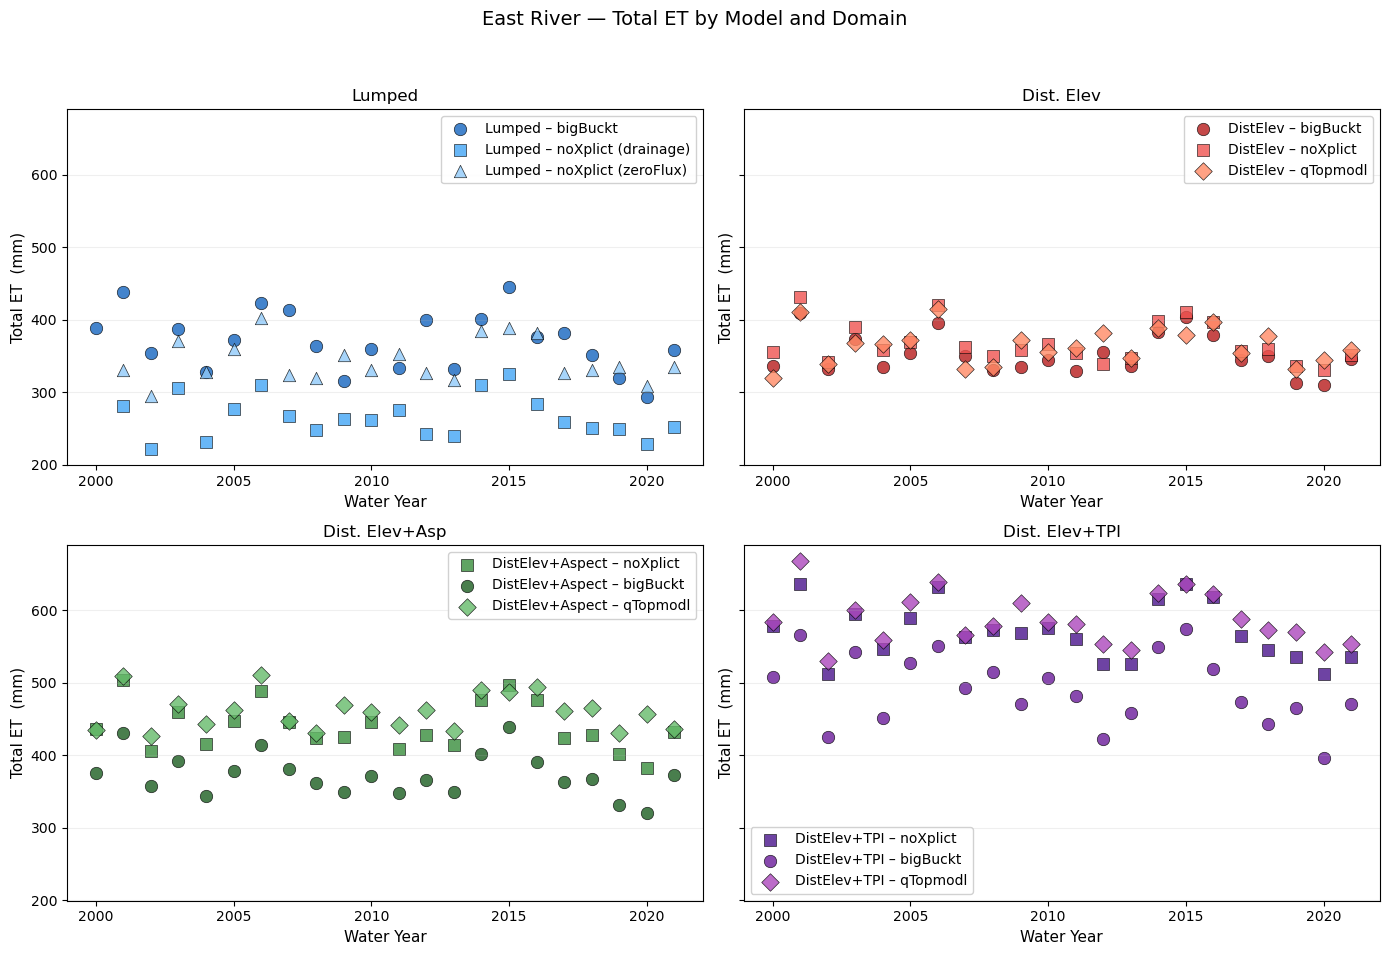

In [219]:
# plot a 2x2 panel plot with bar plots of the Total ET timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        # calculate weighted mean ET

        et_daily = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        et_daily = et_daily.resample('1D').sum()
        et_annual = et_daily.resample('YS-SEP').sum()
        # drop years after 2021
        et_annual = et_annual[et_annual.index.year <= 2020]
        # add 1 year to get water year
        et_annual.index = et_annual.index + pd.offsets.DateOffset(years=1)
        ax.scatter(et_annual.index.year, et_annual.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), s=80, edgecolors='k', linewidths=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Total ET  (mm)', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=10, framealpha=0.9)
# plt.ylim(100,500)
plt.suptitle('East River — Total ET by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


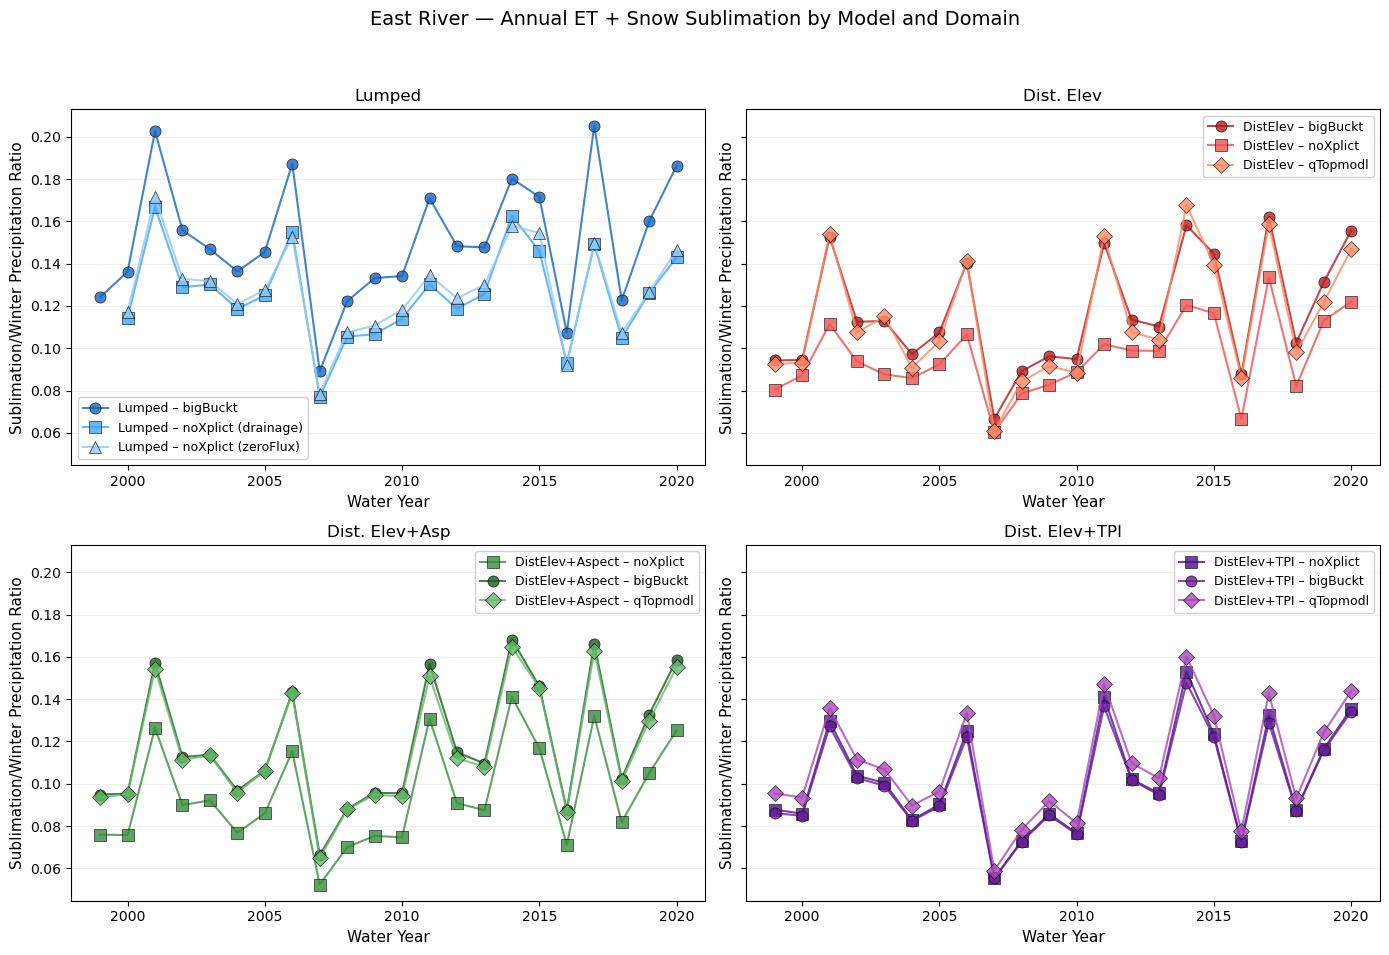

In [188]:
# plot a 2x2 panel plot with bar plots of the annual ET + snow sublimation timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        sub_daily = ((-(ds['scalarSnowSublimation'].where(ds.time.dt.month.isin([12,1,2,3,4])))*3600)).mean(dim='hru').to_pandas()
        winter_ppt = (ds['pptrate'].where(ds.time.dt.month.isin([12,1,2,3,4]))*3600).mean(dim='hru').resample(time='YS-OCT').sum().to_pandas()

        sub_daily = sub_daily.resample('1D').sum()
        sub_annial = sub_daily.resample('YS-OCT').sum()/winter_ppt
        # drop years after 2021
        sub_annial = sub_annial[sub_annial.index.year <= 2021]
        ax.plot(sub_annial.index.year, sub_annial.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), ms=8, markeredgecolor='k', markeredgewidth=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Sublimation/Winter Precipitation Ratio', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
plt.suptitle('East River — Annual ET + Snow Sublimation by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


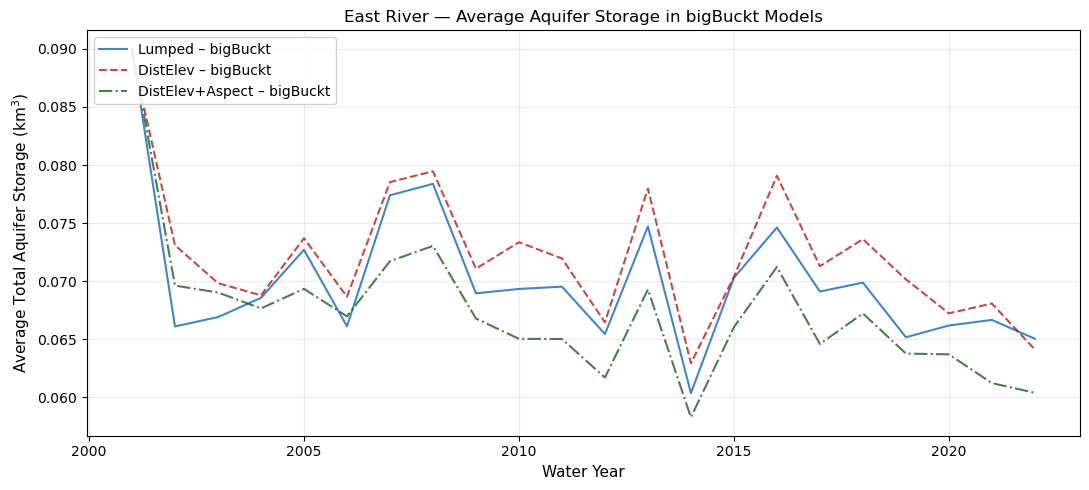

In [332]:
# compare scalarAquiferStorage_mean across bigBuckt models 
import geopandas as gpd
basin_area_m2 = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp")['HRU_area']
fig, ax = plt.subplots(figsize=(11, 5))
for (domain, model_key), sim_df in annual_q_dict.items():
    if model_key != 'bigBuckt':
        continue
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarAquiferStorage_mean' not in ds.data_vars:
        continue
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    aquifer_storage = aquifer_storage.resample('1D').mean()
    aquifer_annual = aquifer_storage.resample('YE-SEP').min()
    # drop years after 2021
    aquifer_annual = aquifer_annual[(aquifer_annual.index.year <= 2021) & (aquifer_annual.index.year >= 2000)]
    # add 1 year to get water year
    aquifer_annual.index = aquifer_annual.index + pd.offsets.DateOffset(years=1)
    ax.plot(aquifer_annual.index.year, aquifer_annual.values*basin_area_m2.mean()/1e9,
            color=style['color'], linestyle=style['ls'], ms=8, markeredgecolor='k', markeredgewidth=0.5,
            linewidth=1.5, alpha=0.8, label=style['label'])
ax.set_xlabel('Water Year', fontsize=11)
ax.set_ylabel('Average Total Aquifer Storage (km$^3$)', fontsize=11)
ax.set_title('East River — Average Aquifer Storage in bigBuckt Models', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

Processing lumped - bigBuckt
Processing lumped - noXplict_drainage
Processing lumped - noXplict_zeroFlux
Processing distributed_elev - bigBuckt
Processing distributed_elev - noXplict_drainage
Processing distributed_elev - qTopmodl
Processing distributed_elevAspect - noXplict_drainage
Processing distributed_elevAspect - bigBuckt
Processing distributed_elevAspect - qTopmodl
Processing distributed_elevTPI - noXplict_drainage
Processing distributed_elevTPI - bigBuckt
Processing distributed_elevTPI - qTopmodl


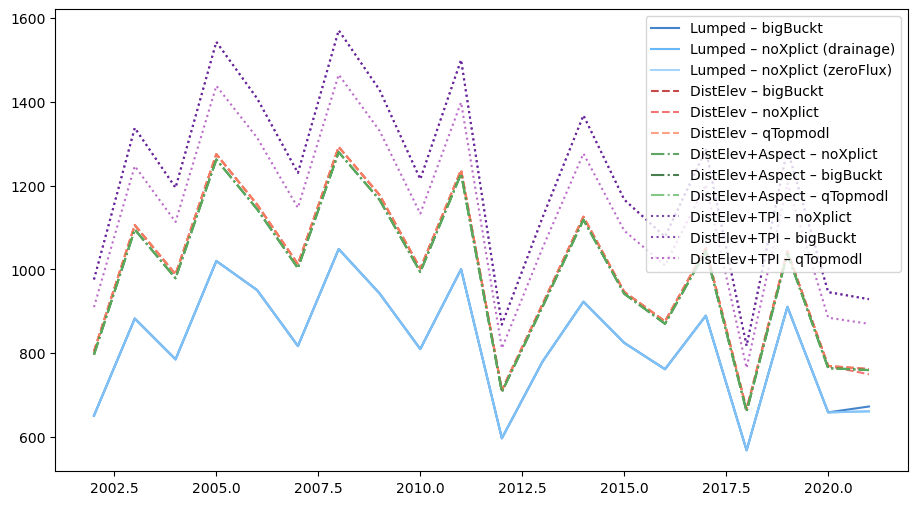

In [189]:
# plot a full water balance P-ET + soil moisture infiltration - drainage
fig, ax = plt.subplots(figsize=(11, 6))
vars_needed = ["pptrate", "scalarTotalET", "scalarSnowSublimation",
               "scalarInfiltration", "scalarSoilDrainage", "averageInstantRunoff", "scalarAquiferStorage_mean",
               "scalarTotalSoilLiq", "scalarCanopyLiq_mean"]

for (domain, model_key), sim_df in annual_q_dict.items():
    print(f"Processing {domain} - {model_key}")
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]

    ds_d = xr.open_dataset(filepath)[vars_needed].mean(dim='hru')

    if model_key == 'bigBuckt':
        storage_var = ds_d["scalarAquiferStorage_mean"].diff(dim='time') * 1000  # change in aquifer storage
    else:
        storage_var = (ds_d["scalarInfiltration"] - ds_d["scalarSoilDrainage"]) * 3600 * 1000
        # storage_var = ds_d["scalarTotalSoilLiq"].diff(dim='time')  # change in soil moisture storage
# ppt - ET - storage_change (positive = storage increase) - canopy storage - runoff

# need to normalize by HRU area to get contributing amount of water
# they are not all equal so averaging across HRUs can be misleading.
    balance_daily = (
        ds_d["pptrate"] * 3600
        # - (-ds_d["scalarTotalET"] - ds_d["scalarSnowSublimation"]) * 3600
        # - (storage_var) 
        # - ds_d['scalarCanopyLiq_mean'].diff(dim='time')
        # - ds_d["averageInstantRunoff"] * 3600 * 1000
    )

    balance_annual = balance_daily.resample(time='YS-OCT').sum().to_pandas()
    balance_annual = balance_annual[(balance_annual.index.year <= 2021) & (balance_annual.index.year > 2000)]
    balance_annual.index = balance_annual.index + pd.offsets.DateOffset(years=1)

    ax.plot(balance_annual.index.year, balance_annual.values,
            color=style["color"], linestyle=style["ls"], ms=8, markeredgecolor="k", markeredgewidth=0.5,
            linewidth=1.5, alpha=0.8, label=style["label"])
plt.legend()

# Spatial Visualization Plots

In [261]:
import geopandas as gpd
shapefile_catchment_dirs = {
    'lumped':              '/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment',
    'distributed_elev':    '/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment',
    'distributed_elevAspect': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment',
    'distributed_elevTPI': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevTPI/shapefiles/catchment',
}

In [266]:
summer_et_mean

<xarray.DataArray (hru: 1)> Size: 8B
array([188.7913747])
Coordinates:
  * hru      (hru) int64 8B 1

In [270]:
gdf

,GRU_ID,HRU_ID,elevClass,avg_elevcl,hru_type,ID,gru_to_seg,GRU_area,HRU_area,center_lon,center_lat,elev_mean,geometry,mean_et,std_et
0,1,1,5,3997.062072,elevClass_within_gru,1,1,7.482517e+08,3.900221e+06,-106.919167,38.979154,3997.061644,"MULTIPOLYGON (((-106.96875 39.02958, -106.9687...",101.662866,10.255793
1,1,2,4,3695.141568,elevClass_within_gru,1,1,7.482517e+08,7.994638e+07,-106.820417,38.974270,3695.141902,"MULTIPOLYGON (((-107.06708 38.99375, -107.0670...",140.136707,12.259245
2,1,3,3,3361.451095,elevClass_within_gru,1,1,7.482517e+08,2.339172e+08,-106.822084,38.897161,3361.451552,"MULTIPOLYGON (((-106.99375 38.94042, -106.9937...",196.642122,21.135470
3,1,4,2,3012.050333,elevClass_within_gru,1,1,7.482517e+08,2.780548e+08,-106.829584,38.841327,3012.050333,"MULTIPOLYGON (((-107.04042 39.00625, -107.0404...",140.023238,11.327079
4,1,5,1,2685.607521,elevClass_within_gru,1,1,7.482517e+08,1.524332e+08,-106.888750,38.807138,2685.607521,"MULTIPOLYGON (((-106.98208 38.94208, -106.9820...",203.231900,24.313133


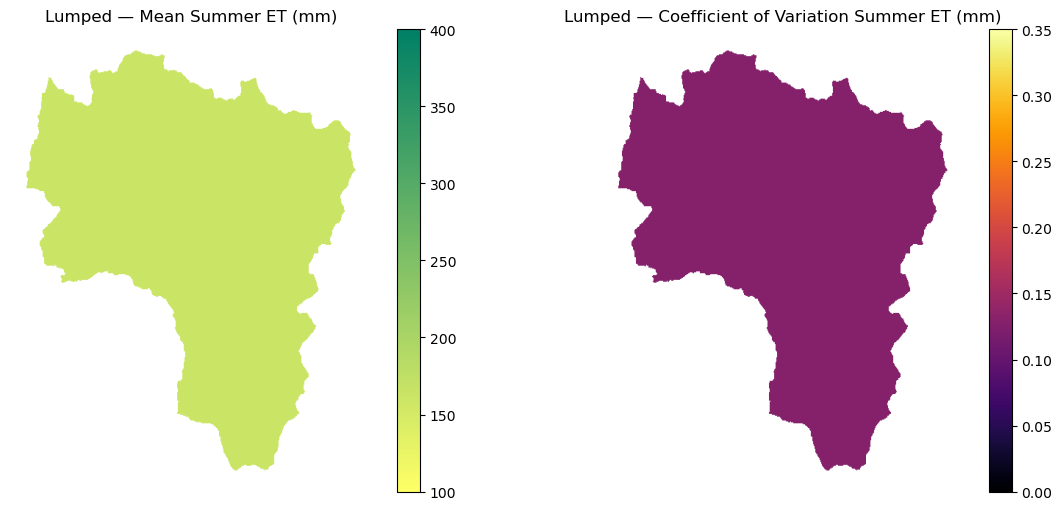

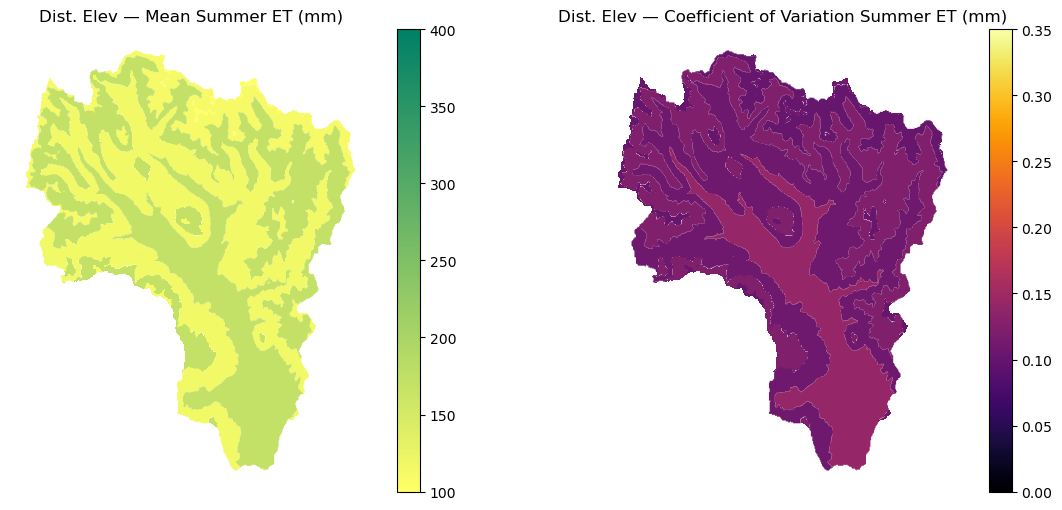

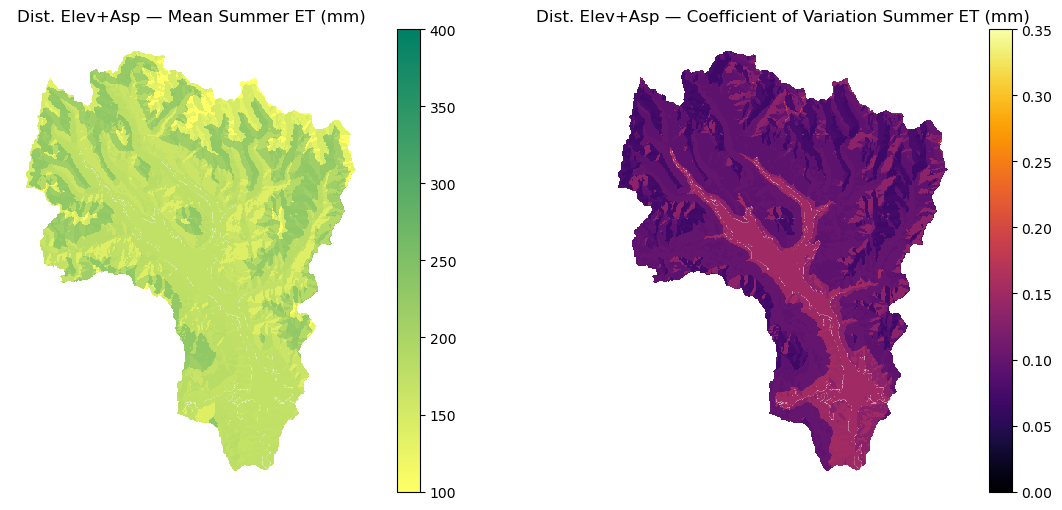

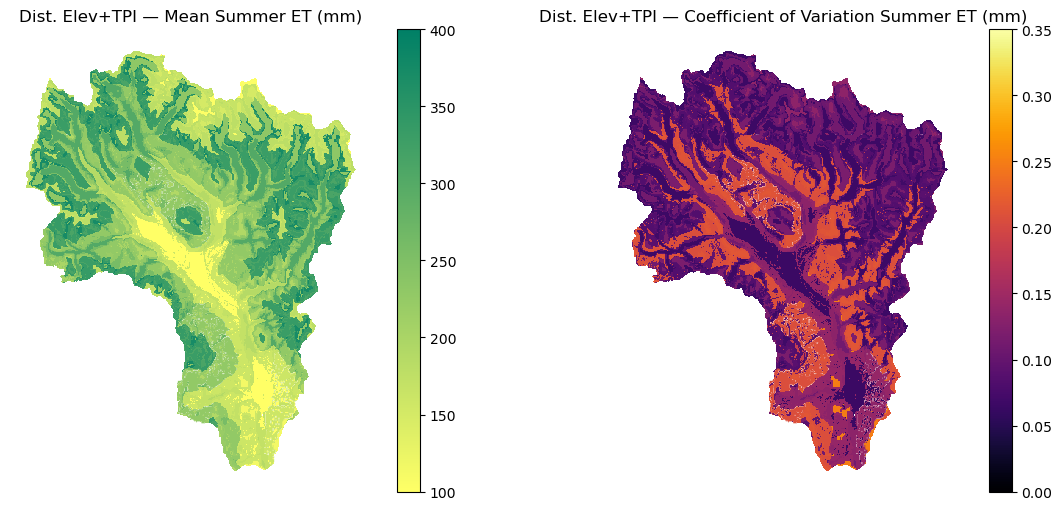

In [304]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarTotalET'  # example variable

for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    months_to_plot = [5,6,7]
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # plot the mean scalarTotalET filled into the basin
    summer_et = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).where(ds.time.dt.month.isin(months_to_plot)).resample(time='YS-APR').sum().sel(time=slice('2002', '2021'))
    summer_et_mean = summer_et.mean(dim='time')
    summer_et_cv = summer_et.std(dim='time') / summer_et.mean(dim='time')
    gdf['mean_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_mean.sel(hru=hru_id).values))
    gdf['cv_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_cv.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_et', cmap='summer_r', legend=True, ax=ax,vmin=100, vmax=400)
    ax.set_title(f"{domain_labels[domain]} — Mean Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_et', cmap='inferno', legend=True, ax=ax, vmin=0, vmax=0.35)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

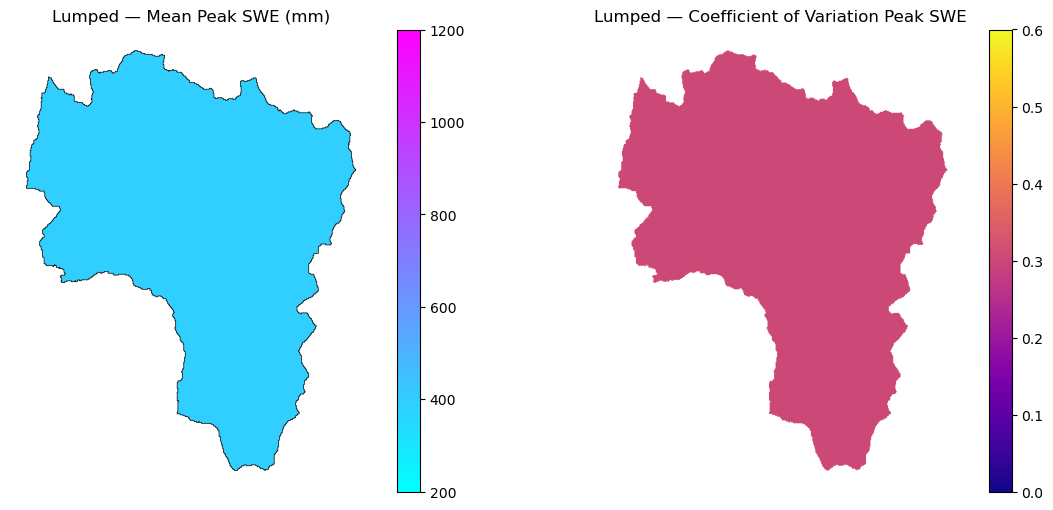

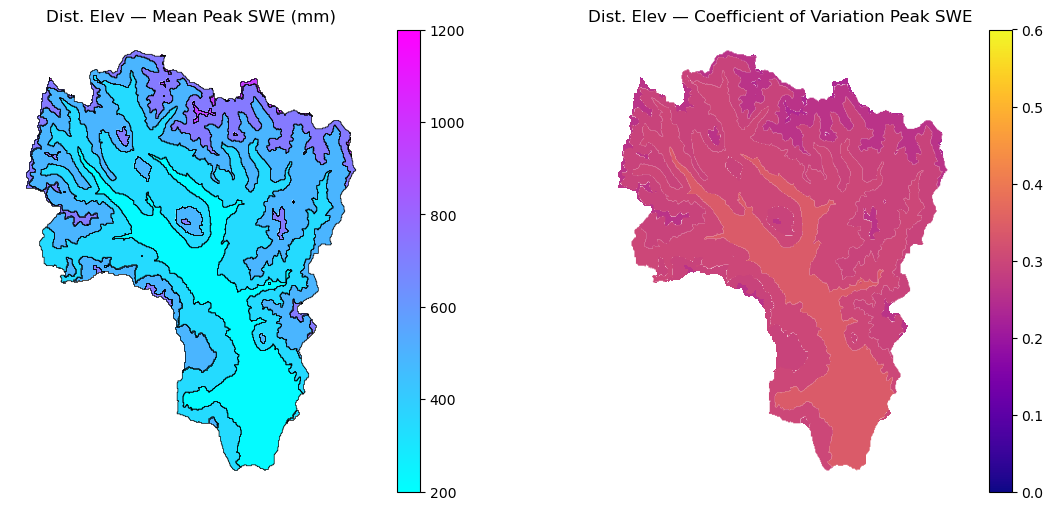

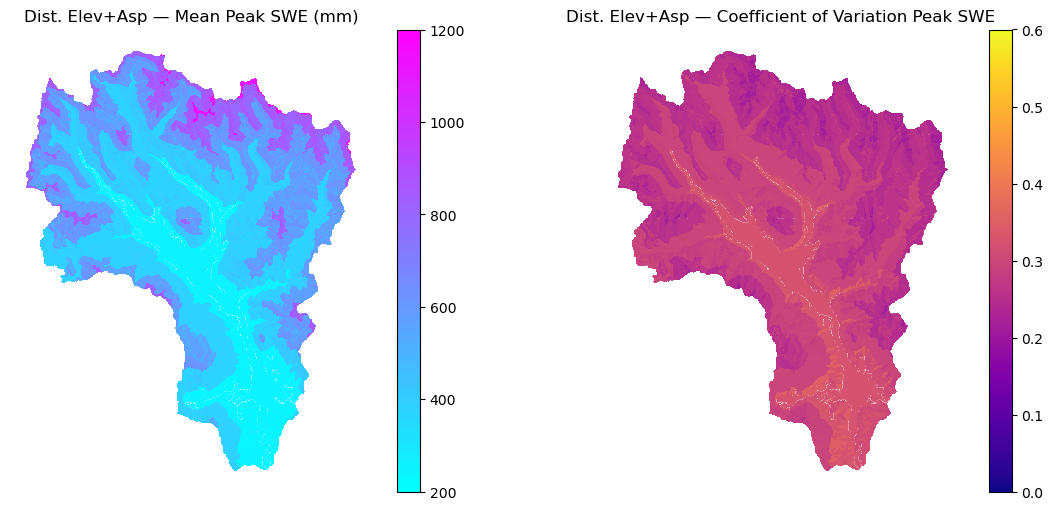

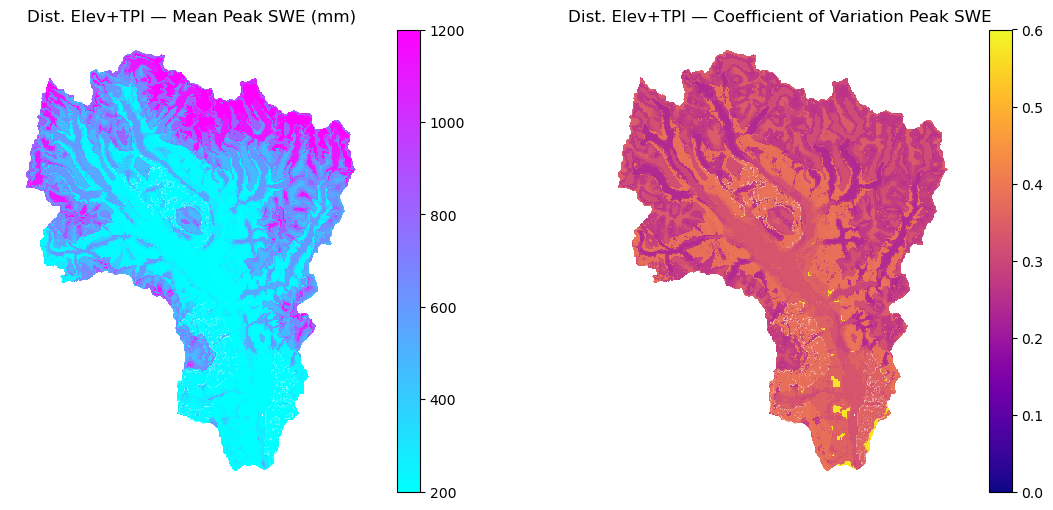

In [305]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarTotalET'  # example variable

for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    months_to_plot = [3,4,5]
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # plot the mean scalarTotalET filled into the basin
    peak_swe = (ds['scalarSWE']).where(ds.time.dt.month.isin(months_to_plot)).resample(time='YE-APR').max().sel(time=slice('2002', '2021'))
    peak_swe_mean = peak_swe.mean(dim='time')
    peak_swe_cv = peak_swe.std(dim='time') / peak_swe_mean
    gdf['mean_peak_swe'] = gdf['HRU_ID'].apply(lambda hru_id: float(peak_swe_mean.sel(hru=hru_id).values))
    gdf['cv_peak_swe'] = gdf['HRU_ID'].apply(lambda hru_id: float(peak_swe_cv.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_peak_swe', cmap='cool', legend=True, ax=ax, vmin=200, vmax=1200)
    # plot hru outlines
    if domain in ['lumped', 'distributed_elev']:
        gdf.boundary.plot(color='k', linewidth=0.5, ax=ax)
    ax.set_title(f"{domain_labels[domain]} — Mean Peak SWE (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_peak_swe', cmap='plasma', legend=True, ax=ax, vmin=0, vmax=0.6)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation Peak SWE ", fontsize=12)
    ax.set_axis_off()